In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os
os.listdir("/content/drive/MyDrive/uidai")


['api_data_aadhar_enrolment.zip',
 'api_data_aadhar_demographic.zip',
 'api_data_aadhar_biometric.zip',
 'api_data_aadhar_enrolment',
 'cleaned',
 'api_data_aadhar_demographic',
 'api_data_aadhar_biometric',
 'analysis',
 'UIDAI_Hackathon_Backup.zip']

In [ ]:
import zipfile

ZIP_PATH = "/content/drive/MyDrive/uidai/api_data_aadhar_enrolment.zip"
EXTRACT_PATH = "/content/drive/MyDrive/uidai"

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_PATH)


In [ ]:
os.listdir("/content/drive/MyDrive/uidai/api_data_aadhar_enrolment")


['api_data_aadhar_enrolment_0_500000.csv',
 'api_data_aadhar_enrolment_1000000_1006029.csv',
 'api_data_aadhar_enrolment_500000_1000000.csv']

In [ ]:
import pandas as pd
import glob

# Locate all enrolment CSV files (Google Drive path)
files = glob.glob("/content/drive/MyDrive/uidai/api_data_aadhar_enrolment/*.csv")

df_list = []

for f in files:
    df = pd.read_csv(f)

    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)

    # Standardise text fields
    df['state'] = df['state'].str.strip().str.title()
    df['district'] = df['district'].str.strip().str.title()

    # Treat pincode as categorical identifier
    df['pincode'] = df['pincode'].astype(str)

    # Validate enrolment counts (no negative values)
    negative_counts = (df[['age_0_5', 'age_5_17', 'age_18_greater']] < 0).sum()
    if negative_counts.any():
        print(f"Warning: Negative enrolment values found in file {f}")
        print(negative_counts)

    df_list.append(df)

# Merge all cleaned chunks
enrolment_clean = pd.concat(df_list, ignore_index=True)

# Duplicate check
duplicate_count = enrolment_clean.duplicated(
    subset=['date', 'state', 'district', 'pincode']
).sum()

print("Duplicate records found:", duplicate_count)

# Remove duplicates (safe)
enrolment_clean = enrolment_clean.drop_duplicates(
    subset=['date',
    'state',
    'district',
    'pincode',
    'age_0_5',
    'age_5_17',
    'age_18_greater']
)

# Final dataset overview
enrolment_clean.info()


Duplicate records found: 23739
<class 'pandas.core.frame.DataFrame'>
Index: 983000 entries, 0 to 1004911
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            983000 non-null  datetime64[ns]
 1   state           983000 non-null  object        
 2   district        983000 non-null  object        
 3   pincode         983000 non-null  object        
 4   age_0_5         983000 non-null  int64         
 5   age_5_17        983000 non-null  int64         
 6   age_18_greater  983000 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 60.0+ MB


In [ ]:
import os

# Create cleaned folder if it doesn't exist
os.makedirs("/content/drive/MyDrive/uidai/cleaned", exist_ok=True)

# Save cleaned enrolment dataset
enrolment_clean.to_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_enrolment_clean_dec2025.csv",
    index=False
)

print("Cleaned enrolment dataset saved successfully.")


Cleaned enrolment dataset saved successfully.


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/uidai/api_data_aadhar_demographic.zip"
extract_path = "/content/drive/MyDrive/uidai/api_data_aadhar_demographic"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Demographic Update dataset unzipped successfully.")
os.listdir(extract_path)


Demographic Update dataset unzipped successfully.


['api_data_aadhar_demographic']

In [ ]:
import os

os.listdir("/content/drive/MyDrive/uidai/api_data_aadhar_demographic/api_data_aadhar_demographic")


['api_data_aadhar_demographic_0_500000.csv',
 'api_data_aadhar_demographic_1000000_1500000.csv',
 'api_data_aadhar_demographic_1500000_2000000.csv',
 'api_data_aadhar_demographic_2000000_2071700.csv',
 'api_data_aadhar_demographic_500000_1000000.csv']

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/uidai/api_data_aadhar_demographic/api_data_aadhar_demographic/api_data_aadhar_demographic_0_500000.csv"
df_demo_sample = pd.read_csv(file_path)

df_demo_sample.head()
df_demo_sample.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   date           500000 non-null  object
 1   state          500000 non-null  object
 2   district       500000 non-null  object
 3   pincode        500000 non-null  int64 
 4   demo_age_5_17  500000 non-null  int64 
 5   demo_age_17_   500000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 22.9+ MB


In [ ]:
import pandas as pd
import glob

files = glob.glob(
    "/content/drive/MyDrive/uidai/api_data_aadhar_demographic/api_data_aadhar_demographic/*.csv"
)

for f in files:
    print("FILE:", f.split("/")[-1])
    print(pd.read_csv(f, nrows=0).columns.tolist())
    print("-----")


FILE: api_data_aadhar_demographic_0_500000.csv
['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
-----
FILE: api_data_aadhar_demographic_1000000_1500000.csv
['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
-----
FILE: api_data_aadhar_demographic_1500000_2000000.csv
['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
-----
FILE: api_data_aadhar_demographic_2000000_2071700.csv
['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
-----
FILE: api_data_aadhar_demographic_500000_1000000.csv
['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
-----


In [ ]:
import pandas as pd
import glob

files = glob.glob(
    "/content/drive/MyDrive/uidai/api_data_aadhar_demographic/api_data_aadhar_demographic/*.csv"
)

df_list = []

for f in files:
    df = pd.read_csv(f)

    # STEP 1: Convert date to datetime
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)

    # STEP 2: Standardise text fields
    df['state'] = df['state'].str.strip().str.title()
    df['district'] = df['district'].str.strip().str.title()

    # STEP 3: Treat pincode as categorical identifier
    df['pincode'] = df['pincode'].astype(str)

    # STEP 4: Validate update counts (no negative values)
    negative_counts = (df[['demo_age_5_17', 'demo_age_17_']] < 0).sum()
    if negative_counts.any():
        print(f"Warning: Negative update values found in file {f}")
        print(negative_counts)

    df_list.append(df)

# STEP 5: Merge all cleaned chunks
demographic_clean = pd.concat(df_list, ignore_index=True)

# STEP 6: Duplicate check — EXACT aggregate duplicates only
duplicate_count = demographic_clean.duplicated(
    subset=[
        'date',
        'state',
        'district',
        'pincode',
        'demo_age_5_17',
        'demo_age_17_'
    ]
).sum()

print("Exact duplicate aggregate records:", duplicate_count)

# Remove duplicates only if present
if duplicate_count > 0:
    demographic_clean = demographic_clean.drop_duplicates(
        subset=[
            'date',
            'state',
            'district',
            'pincode',
            'demo_age_5_17',
            'demo_age_17_'
        ]
    )

# Final dataset overview
demographic_clean.info()


Exact duplicate aggregate records: 473688
<class 'pandas.core.frame.DataFrame'>
Index: 1598012 entries, 0 to 2061699
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   date           1598012 non-null  datetime64[ns]
 1   state          1598012 non-null  object        
 2   district       1598012 non-null  object        
 3   pincode        1598012 non-null  object        
 4   demo_age_5_17  1598012 non-null  int64         
 5   demo_age_17_   1598012 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 85.3+ MB


In [ ]:
# Check that no exact duplicates remain
demographic_clean.duplicated(
    subset=[
        'date','state','district','pincode',
        'demo_age_5_17','demo_age_17_'
    ]
).sum()


np.int64(0)

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/uidai/cleaned", exist_ok=True)

demographic_clean.to_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_demographic_update_clean_dec2025.csv",
    index=False
)

print("Cleaned demographic update dataset saved successfully.")


Cleaned demographic update dataset saved successfully.


In [ ]:
import os

os.listdir("/content/drive/MyDrive/uidai")


['api_data_aadhar_enrolment.zip',
 'api_data_aadhar_enrolment',
 'cleaned',
 'api_data_aadhar_demographic.zip',
 'api_data_aadhar_demographic',
 'api_data_aadhar_biometric.zip']

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/uidai/api_data_aadhar_biometric.zip"
extract_path = "/content/drive/MyDrive/uidai/api_data_aadhar_biometric"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Biometric Update dataset unzipped.")
os.listdir(extract_path)


Biometric Update dataset unzipped.


['api_data_aadhar_biometric']

In [ ]:
os.listdir("/content/drive/MyDrive/uidai/api_data_aadhar_biometric/api_data_aadhar_biometric")


['api_data_aadhar_biometric_0_500000.csv',
 'api_data_aadhar_biometric_1000000_1500000.csv',
 'api_data_aadhar_biometric_1500000_1861108.csv',
 'api_data_aadhar_biometric_500000_1000000.csv']

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/uidai/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv"
df_bio_sample = pd.read_csv(file_path)

df_bio_sample.head()
df_bio_sample.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   date          500000 non-null  object
 1   state         500000 non-null  object
 2   district      500000 non-null  object
 3   pincode       500000 non-null  int64 
 4   bio_age_5_17  500000 non-null  int64 
 5   bio_age_17_   500000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 22.9+ MB


In [ ]:
import pandas as pd
import glob

files = glob.glob(
    "/content/drive/MyDrive/uidai/api_data_aadhar_biometric/api_data_aadhar_biometric/*.csv"
)

for f in files:
    print("FILE:", f.split("/")[-1])
    print(pd.read_csv(f, nrows=0).columns.tolist())
    print("-----")


FILE: api_data_aadhar_biometric_0_500000.csv
['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']
-----
FILE: api_data_aadhar_biometric_1000000_1500000.csv
['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']
-----
FILE: api_data_aadhar_biometric_1500000_1861108.csv
['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']
-----
FILE: api_data_aadhar_biometric_500000_1000000.csv
['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']
-----


In [ ]:
import pandas as pd
import glob

files = glob.glob(
    "/content/drive/MyDrive/uidai/api_data_aadhar_biometric/api_data_aadhar_biometric/*.csv"
)

df_list = []

for f in files:
    df = pd.read_csv(f)

    # STEP 1: Convert date to datetime
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)

    # STEP 2: Standardise geographic text
    df['state'] = df['state'].str.strip().str.title()
    df['district'] = df['district'].str.strip().str.title()

    # STEP 3: Treat pincode as categorical identifier
    df['pincode'] = df['pincode'].astype(str)

    # STEP 4: Validate biometric update counts
    negative_counts = (df[['bio_age_5_17', 'bio_age_17_']] < 0).sum()
    if negative_counts.any():
        print(f"Warning: Negative biometric values found in file {f}")
        print(negative_counts)

    df_list.append(df)

# STEP 5: Merge all cleaned chunks
biometric_clean = pd.concat(df_list, ignore_index=True)

# STEP 6: Exact aggregate duplicate detection
duplicate_count = biometric_clean.duplicated(
    subset=[
        'date',
        'state',
        'district',
        'pincode',
        'bio_age_5_17',
        'bio_age_17_'
    ]
).sum()

print("Exact duplicate aggregate records:", duplicate_count)

# Remove duplicates safely
if duplicate_count > 0:
    biometric_clean = biometric_clean.drop_duplicates(
        subset=[
            'date',
            'state',
            'district',
            'pincode',
            'bio_age_5_17',
            'bio_age_17_'
        ]
    )

# Final dataset overview
biometric_clean.info()


Exact duplicate aggregate records: 94949
<class 'pandas.core.frame.DataFrame'>
Index: 1766159 entries, 0 to 1860557
Data columns (total 6 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   state         object        
 2   district      object        
 3   pincode       object        
 4   bio_age_5_17  int64         
 5   bio_age_17_   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 94.3+ MB


In [ ]:
import os

os.makedirs("/content/drive/MyDrive/uidai/cleaned", exist_ok=True)

biometric_clean.to_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_biometric_update_clean_dec2025.csv",
    index=False
)

print("Cleaned biometric update dataset saved successfully.")


Cleaned biometric update dataset saved successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

os.listdir("/content/drive/MyDrive/uidai")


['api_data_aadhar_enrolment.zip',
 'api_data_aadhar_demographic.zip',
 'api_data_aadhar_biometric.zip',
 'api_data_aadhar_enrolment',
 'cleaned',
 'api_data_aadhar_demographic',
 'api_data_aadhar_biometric']

In [ ]:
#loading the dataset

import pandas as pd

enrolment_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_enrolment_clean_dec2025.csv",
    parse_dates=['date']
)


In [ ]:
#loading the dataset
demographic_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_demographic_update_clean_dec2025.csv",
    parse_dates=['date']
)


In [ ]:
#loading the dataset
biometric_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_biometric_update_clean_dec2025.csv",
    parse_dates=['date']
)


In [ ]:
enrolment_clean['state'].nunique()
sorted(enrolment_clean['state'].unique())


['100000',
 'Andaman & Nicobar Islands',
 'Andaman And Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra & Nagar Haveli',
 'Dadra And Nagar Haveli',
 'Dadra And Nagar Haveli And Daman And Diu',
 'Daman & Diu',
 'Daman And Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu & Kashmir',
 'Jammu And Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Orissa',
 'Pondicherry',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'The Dadra And Nagar Haveli And Daman And Diu',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West  Bengal',
 'West Bangal',
 'West Bengal',
 'Westbengal']

In [ ]:
import numpy as np

enrolment_clean['state'] = enrolment_clean['state'].replace('100000', np.nan)

# Drop rows with invalid state
enrolment_clean = enrolment_clean.dropna(subset=['state'])


In [ ]:
# ------------------------------------------------------------
# STEP 1: Dictionary to standardize Indian state / UT names
# ------------------------------------------------------------
# Key   -> Incorrect / alternate / old / misspelled state names
# Value -> Correct and standardized state names
# NOTE:
# - Mapping is CASE-SENSITIVE
# - Only EXACT matches will be replaced
# ------------------------------------------------------------

state_mapping = {
    # Andaman & Nicobar Islands variations
    "Andaman & Nicobar Islands": "Andaman And Nicobar Islands",

    # Jammu & Kashmir variations
    "Jammu & Kashmir": "Jammu And Kashmir",

    # Dadra & Nagar Haveli / Daman & Diu variations
    "Dadra & Nagar Haveli": "Dadra And Nagar Haveli",
    "Daman & Diu": "Daman And Diu",
    "The Dadra And Nagar Haveli And Daman And Diu":
        "Dadra And Nagar Haveli And Daman And Diu",

    # Old state names officially changed
    "Orissa": "Odisha",
    "Pondicherry": "Puducherry",

    # Common spelling / spacing mistakes for West Bengal
    "West  Bengal": "West Bengal",   # double space
    "West Bangal": "West Bengal",    # spelling mistake
    "Westbengal": "West Bengal"      # missing space
}

print("STEP 1 COMPLETE: State mapping dictionary created")
print("--------------------------------------------------")
print(state_mapping)
print("\n")


# ------------------------------------------------------------
# STEP 2: Display original unique state values (before cleaning)
# ------------------------------------------------------------

print("STEP 2: UNIQUE STATE VALUES BEFORE CLEANING")
print("--------------------------------------------------")
print(enrolment_clean['state'].unique())
print("\n")


# ------------------------------------------------------------
# STEP 3: Basic text normalization
# ------------------------------------------------------------
# - strip() removes leading/trailing spaces
# - title() converts text to Title Case
#   Example: 'west bengal ' -> 'West Bengal'
# ------------------------------------------------------------

enrolment_clean['state'] = (
    enrolment_clean['state']
    .astype(str)        # Ensure column is string type
    .str.strip()        # Remove extra spaces
    .str.title()        # Normalize capitalization
)

print("STEP 3 COMPLETE: Text normalization applied")
print("--------------------------------------------------")
print(enrolment_clean['state'].unique())
print("\n")


# ------------------------------------------------------------
# STEP 4: Replace incorrect names using the mapping dictionary
# ------------------------------------------------------------
# This replaces ONLY exact matches found in state_mapping keys
# ------------------------------------------------------------

enrolment_clean['state'] = enrolment_clean['state'].replace(state_mapping)

print("STEP 4 COMPLETE: State name standardization applied")
print("--------------------------------------------------")
print(enrolment_clean['state'].unique())
print("\n")


# ------------------------------------------------------------
# STEP 5: Final verification - count records per state
# ------------------------------------------------------------
# This helps confirm no unexpected names remain
# ------------------------------------------------------------

print("STEP 5: FINAL STATE COUNTS (VERIFICATION)")
print("--------------------------------------------------")
print(enrolment_clean['state'].value_counts())
print("\n")


# ------------------------------------------------------------
# CLEANING PROCESS FINISHED
# ------------------------------------------------------------

print("STATE NAME CLEANING SUCCESSFULLY COMPLETED ✅")


STEP 1 COMPLETE: State mapping dictionary created
--------------------------------------------------
{'Andaman & Nicobar Islands': 'Andaman And Nicobar Islands', 'Jammu & Kashmir': 'Jammu And Kashmir', 'Dadra & Nagar Haveli': 'Dadra And Nagar Haveli', 'Daman & Diu': 'Daman And Diu', 'The Dadra And Nagar Haveli And Daman And Diu': 'Dadra And Nagar Haveli And Daman And Diu', 'Orissa': 'Odisha', 'Pondicherry': 'Puducherry', 'West  Bengal': 'West Bengal', 'West Bangal': 'West Bengal', 'Westbengal': 'West Bengal'}


STEP 2: UNIQUE STATE VALUES BEFORE CLEANING
--------------------------------------------------
['Meghalaya' 'Karnataka' 'Uttar Pradesh' 'Bihar' 'Maharashtra' 'Haryana'
 'Rajasthan' 'Punjab' 'Delhi' 'Madhya Pradesh' 'West Bengal' 'Assam'
 'Uttarakhand' 'Gujarat' 'Andhra Pradesh' 'Tamil Nadu' 'Chhattisgarh'
 'Jharkhand' 'Nagaland' 'Manipur' 'Telangana' 'Tripura' 'Mizoram'
 'Jammu And Kashmir' 'Chandigarh' 'Sikkim' 'Odisha' 'Kerala'
 'The Dadra And Nagar Haveli And Daman And Diu' '

In [ ]:
# ------------------------------------------------------------
# STEP 6: Mapping to merge old UTs into the new combined UT
# ------------------------------------------------------------
# Dadra & Nagar Haveli and Daman & Diu were merged in 2020.
# Any remaining separate occurrences must be standardized
# into ONE official UT name.
# ------------------------------------------------------------

merge_ut_mapping = {
    "Dadra And Nagar Haveli": "Dadra And Nagar Haveli And Daman And Diu",
    "Daman And Diu": "Dadra And Nagar Haveli And Daman And Diu"
}

print("STEP 6: UT MERGE MAPPING DEFINED")
print("--------------------------------------------------")
print(merge_ut_mapping)
print("\n")


# ------------------------------------------------------------
# STEP 7: Apply UT merge mapping
# ------------------------------------------------------------
# This replaces any occurrence of the old UT names
# with the officially merged UT name.
# ------------------------------------------------------------

enrolment_clean['state'] = enrolment_clean['state'].replace(merge_ut_mapping)

print("STEP 7 COMPLETE: UTs successfully merged")
print("--------------------------------------------------")
print(sorted(enrolment_clean['state'].unique()))
print("\n")


# ------------------------------------------------------------
# STEP 8: Verify number of unique states / UTs
# ------------------------------------------------------------
# This count should now match the expected official count
# based on your dataset scope.
# ------------------------------------------------------------

unique_state_count = enrolment_clean['state'].nunique()

print("STEP 8: FINAL UNIQUE STATE / UT COUNT")
print("--------------------------------------------------")
print(f"Total unique states / UTs after cleaning: {unique_state_count}")
print("\n")


# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------

print("STATE / UT MERGING AND STANDARDIZATION COMPLETED SUCCESSFULLY ✅")


STEP 6: UT MERGE MAPPING DEFINED
--------------------------------------------------
{'Dadra And Nagar Haveli': 'Dadra And Nagar Haveli And Daman And Diu', 'Daman And Diu': 'Dadra And Nagar Haveli And Daman And Diu'}


STEP 7 COMPLETE: UTs successfully merged
--------------------------------------------------
['100000', 'Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli And Daman And Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


STEP 8: FINAL UNIQUE STATE / UT COUNT
--------------------------------------------------
Total unique states / UTs after cleaning: 37


STATE / UT MERGIN

In [ ]:
demographic_clean['state'].nunique()
sorted(demographic_clean['state'].unique())



['100000',
 'Andaman & Nicobar Islands',
 'Andaman And Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Balanagar',
 'Bihar',
 'Chandigarh',
 'Chhatisgarh',
 'Chhattisgarh',
 'Dadra & Nagar Haveli',
 'Dadra And Nagar Haveli',
 'Dadra And Nagar Haveli And Daman And Diu',
 'Daman & Diu',
 'Daman And Diu',
 'Darbhanga',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jaipur',
 'Jammu & Kashmir',
 'Jammu And Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madanapalle',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Nagpur',
 'Odisha',
 'Orissa',
 'Pondicherry',
 'Puducherry',
 'Punjab',
 'Puttenahalli',
 'Raja Annamalai Puram',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'Uttaranchal',
 'West  Bengal',
 'West Bangal',
 'West Bengal',
 'West Bengli',
 'Westbengal']

In [ ]:
valid_states = set(enrolment_clean['state'].unique())

print("Number of valid states / UTs:", len(valid_states))
sorted(valid_states)


Number of valid states / UTs: 36


['Andaman And Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra And Nagar Haveli And Daman And Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu And Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

In [ ]:
invalid_demo_states = set(demographic_clean['state']) - valid_states
print("Invalid state labels found in demographic dataset:")
sorted(invalid_demo_states)


Invalid state labels found in demographic dataset:


['100000',
 'Andaman & Nicobar Islands',
 'Balanagar',
 'Chhatisgarh',
 'Dadra & Nagar Haveli',
 'Dadra And Nagar Haveli',
 'Daman & Diu',
 'Daman And Diu',
 'Darbhanga',
 'Jaipur',
 'Jammu & Kashmir',
 'Madanapalle',
 'Nagpur',
 'Orissa',
 'Pondicherry',
 'Puttenahalli',
 'Raja Annamalai Puram',
 'Uttaranchal',
 'West  Bengal',
 'West Bangal',
 'West Bengli',
 'Westbengal']

In [ ]:
import pandas as pd
import numpy as np

# Enrolment (gold standard for valid states)
enrolment_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_enrolment_clean_dec2025.csv",
    parse_dates=['date']
)

# Demographic (needs final state validation & drop)
demographic_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_demographic_update_clean_dec2025.csv",
    parse_dates=['date']
)

# Biometric (we'll inspect next)
biometric_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_biometric_update_clean_dec2025.csv",
    parse_dates=['date']
)



In [ ]:
state_mapping = {
    "Andaman & Nicobar Islands": "Andaman And Nicobar Islands",
    "Jammu & Kashmir": "Jammu And Kashmir",
    "Dadra & Nagar Haveli": "Dadra And Nagar Haveli",
    "Daman & Diu": "Daman And Diu",
    "The Dadra And Nagar Haveli And Daman And Diu":
        "Dadra And Nagar Haveli And Daman And Diu",
    "Orissa": "Odisha",
    "Pondicherry": "Puducherry",
    "West  Bengal": "West Bengal",
    "West Bangal": "West Bengal",
    "Westbengal": "West Bengal",
    "West Bengli": "West Bengal",
    "Chhatisgarh": "Chhattisgarh",
    "Uttaranchal": "Uttarakhand"
}

merge_ut_mapping = {
    "Dadra And Nagar Haveli": "Dadra And Nagar Haveli And Daman And Diu",
    "Daman And Diu": "Dadra And Nagar Haveli And Daman And Diu"
}

# Text normalization
demographic_clean['state'] = (
    demographic_clean['state']
    .astype(str)
    .str.strip()
    .str.title()
)

# Replace numeric junk
demographic_clean['state'] = demographic_clean['state'].replace('100000', np.nan)

# Apply mappings
demographic_clean['state'] = demographic_clean['state'].replace(state_mapping)
demographic_clean['state'] = demographic_clean['state'].replace(merge_ut_mapping)

valid_states = set(enrolment_clean['state'].unique())

invalid_demo_states = {
    s for s in demographic_clean['state']
    if pd.notna(s)
} - valid_states

sorted(invalid_demo_states)




['Balanagar',
 'Darbhanga',
 'Jaipur',
 'Madanapalle',
 'Nagpur',
 'Nan',
 'Puttenahalli',
 'Raja Annamalai Puram']

In [ ]:
before = len(demographic_clean)

demographic_clean = demographic_clean[
    demographic_clean['state'].isin(valid_states)
].copy()

after = len(demographic_clean)

print("Rows before:", before)
print("Rows after :", after)
print("Rows dropped:", before - after)


Rows before: 1598012
Rows after : 1598003
Rows dropped: 9


In [ ]:
demographic_clean['state'].nunique()
set(demographic_clean['state']) == set(enrolment_clean['state'])


False

In [ ]:
sorted(set(enrolment_clean['state']) - set(demographic_clean['state']))


['100000',
 'Andaman & Nicobar Islands',
 'Dadra & Nagar Haveli',
 'Dadra And Nagar Haveli',
 'Daman & Diu',
 'Daman And Diu',
 'Jammu & Kashmir',
 'Orissa',
 'Pondicherry',
 'The Dadra And Nagar Haveli And Daman And Diu',
 'West  Bengal',
 'West Bangal',
 'Westbengal']

In [ ]:
import pandas as pd
import numpy as np

enrolment_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_enrolment_clean_dec2025.csv"
)

demographic_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_demographic_update_clean_dec2025.csv"
)



In [ ]:
print("ENROLMENT STATES:")
print(len(enrolment_clean['state'].unique()))
print(sorted(enrolment_clean['state'].unique()))


ENROLMENT STATES:
37
['100000', 'Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli And Daman And Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [ ]:
enrolment_clean.to_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_enrolment_clean_final.csv",
    index=False
)

print("Final enrolment dataset saved to Drive ✅")


Final enrolment dataset saved to Drive ✅


In [ ]:
import pandas as pd

enrolment_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_enrolment_clean_final.csv"
)

demographic_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_demographic_update_clean_dec2025.csv"
)


In [ ]:
enrolment_clean['state'].nunique()
sorted(enrolment_clean['state'].unique())


['100000',
 'Andaman And Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra And Nagar Haveli And Daman And Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu And Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

In [ ]:
import numpy as np

# Replace invalid numeric-like state with NaN
enrolment_clean['state'] = enrolment_clean['state'].replace('100000', np.nan)

# Drop rows with invalid state
before = len(enrolment_clean)
enrolment_clean = enrolment_clean.dropna(subset=['state'])
after = len(enrolment_clean)

print("Rows before:", before)
print("Rows after :", after)
print("Rows dropped:", before - after)


Rows before: 983000
Rows after : 982979
Rows dropped: 21


In [ ]:
enrolment_clean['state'].nunique()
sorted(enrolment_clean['state'].unique())


['Andaman And Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra And Nagar Haveli And Daman And Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu And Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

In [ ]:
enrolment_clean.to_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_enrolment_clean_final.csv",
    index=False
)

print("Enrolment dataset FINAL and saved ✅")


Enrolment dataset FINAL and saved ✅


In [ ]:
import pandas as pd

enrolment_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_enrolment_clean_final.csv"
)

demographic_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_demographic_update_clean_dec2025.csv"
)


In [ ]:
sorted(set(demographic_clean['state']) - set(enrolment_clean['state']))


['100000',
 'Andaman & Nicobar Islands',
 'Balanagar',
 'Chhatisgarh',
 'Dadra & Nagar Haveli',
 'Dadra And Nagar Haveli',
 'Daman & Diu',
 'Daman And Diu',
 'Darbhanga',
 'Jaipur',
 'Jammu & Kashmir',
 'Madanapalle',
 'Nagpur',
 'Orissa',
 'Pondicherry',
 'Puttenahalli',
 'Raja Annamalai Puram',
 'Uttaranchal',
 'West  Bengal',
 'West Bangal',
 'West Bengli',
 'Westbengal']

In [ ]:
import pandas as pd

demographic_clean = pd.read_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_demographic_update_clean_dec2025.csv"
)


In [ ]:
sorted(demographic_clean['state'].unique())
demographic_clean['state'].nunique()


58

In [ ]:
demo_states = sorted(demographic_clean['state'].dropna().unique())
len(demo_states), demo_states


(58,
 ['100000',
  'Andaman & Nicobar Islands',
  'Andaman And Nicobar Islands',
  'Andhra Pradesh',
  'Arunachal Pradesh',
  'Assam',
  'Balanagar',
  'Bihar',
  'Chandigarh',
  'Chhatisgarh',
  'Chhattisgarh',
  'Dadra & Nagar Haveli',
  'Dadra And Nagar Haveli',
  'Dadra And Nagar Haveli And Daman And Diu',
  'Daman & Diu',
  'Daman And Diu',
  'Darbhanga',
  'Delhi',
  'Goa',
  'Gujarat',
  'Haryana',
  'Himachal Pradesh',
  'Jaipur',
  'Jammu & Kashmir',
  'Jammu And Kashmir',
  'Jharkhand',
  'Karnataka',
  'Kerala',
  'Ladakh',
  'Lakshadweep',
  'Madanapalle',
  'Madhya Pradesh',
  'Maharashtra',
  'Manipur',
  'Meghalaya',
  'Mizoram',
  'Nagaland',
  'Nagpur',
  'Odisha',
  'Orissa',
  'Pondicherry',
  'Puducherry',
  'Punjab',
  'Puttenahalli',
  'Raja Annamalai Puram',
  'Rajasthan',
  'Sikkim',
  'Tamil Nadu',
  'Telangana',
  'Tripura',
  'Uttar Pradesh',
  'Uttarakhand',
  'Uttaranchal',
  'West  Bengal',
  'West Bangal',
  'West Bengal',
  'West Bengli',
  'Westbengal']

In [ ]:
import numpy as np

state_fix = {
    "Andaman & Nicobar Islands": "Andaman And Nicobar Islands",
    "Orissa": "Odisha",
    "Pondicherry": "Puducherry",
    "Uttaranchal": "Uttarakhand",
    "Chhatisgarh": "Chhattisgarh",
    "Jammu & Kashmir": "Jammu And Kashmir",
    "West  Bengal": "West Bengal",
    "West Bangal": "West Bengal",
    "West Bengli": "West Bengal",
    "Westbengal": "West Bengal",
    "Dadra & Nagar Haveli": "Dadra And Nagar Haveli And Daman And Diu",
    "Dadra And Nagar Haveli": "Dadra And Nagar Haveli And Daman And Diu",
    "Daman & Diu": "Dadra And Nagar Haveli And Daman And Diu",
    "Daman And Diu": "Dadra And Nagar Haveli And Daman And Diu",
}
demographic_clean['state'] = (
    demographic_clean['state']
    .astype(str)
    .str.strip()
    .str.title()
    .replace(state_fix)
)

# Remove numeric junk
demographic_clean['state'] = demographic_clean['state'].replace('100000', np.nan)
valid_states = set(enrolment_clean['state'].unique())

before = len(demographic_clean)

demographic_clean = demographic_clean[
    demographic_clean['state'].isin(valid_states)
].copy()

after = len(demographic_clean)

print("Rows before:", before)
print("Rows after :", after)
print("Rows dropped:", before - after)



Rows before: 1598012
Rows after : 1598003
Rows dropped: 9


In [ ]:
demographic_clean['state'].nunique()
sorted(demographic_clean['state'].unique())


['Andaman And Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra And Nagar Haveli And Daman And Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu And Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

In [ ]:
demographic_clean.to_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_demographic_update_clean_final.csv",
    index=False
)

print("Demographic dataset cleaned & frozen ✅")


Demographic dataset cleaned & frozen ✅


In [ ]:
bio_states = sorted(biometric_clean['state'].dropna().unique())
len(bio_states), bio_states


(50,
 ['Andaman & Nicobar Islands',
  'Andaman And Nicobar Islands',
  'Andhra Pradesh',
  'Arunachal Pradesh',
  'Assam',
  'Bihar',
  'Chandigarh',
  'Chhatisgarh',
  'Chhattisgarh',
  'Dadra & Nagar Haveli',
  'Dadra And Nagar Haveli',
  'Dadra And Nagar Haveli And Daman And Diu',
  'Daman & Diu',
  'Daman And Diu',
  'Delhi',
  'Goa',
  'Gujarat',
  'Haryana',
  'Himachal Pradesh',
  'Jammu & Kashmir',
  'Jammu And Kashmir',
  'Jharkhand',
  'Karnataka',
  'Kerala',
  'Ladakh',
  'Lakshadweep',
  'Madhya Pradesh',
  'Maharashtra',
  'Manipur',
  'Meghalaya',
  'Mizoram',
  'Nagaland',
  'Odisha',
  'Orissa',
  'Pondicherry',
  'Puducherry',
  'Punjab',
  'Rajasthan',
  'Sikkim',
  'Tamil Nadu',
  'Tamilnadu',
  'Telangana',
  'Tripura',
  'Uttar Pradesh',
  'Uttarakhand',
  'Uttaranchal',
  'West  Bengal',
  'West Bangal',
  'West Bengal',
  'Westbengal'])

In [ ]:
import numpy as np

state_fix = {
    "Andaman & Nicobar Islands": "Andaman And Nicobar Islands",
    "Orissa": "Odisha",
    "Pondicherry": "Puducherry",
    "Uttaranchal": "Uttarakhand",
    "Chhatisgarh": "Chhattisgarh",
    "Jammu & Kashmir": "Jammu And Kashmir",
    "West  Bengal": "West Bengal",
    "West Bangal": "West Bengal",
    "West Bengli": "West Bengal",
    "Westbengal": "West Bengal",
    "Dadra & Nagar Haveli": "Dadra And Nagar Haveli And Daman And Diu",
    "Dadra And Nagar Haveli": "Dadra And Nagar Haveli And Daman And Diu",
    "Daman & Diu": "Dadra And Nagar Haveli And Daman And Diu",
    "Daman And Diu": "Dadra And Nagar Haveli And Daman And Diu",
}

biometric_clean['state'] = (
    biometric_clean['state']
    .astype(str)
    .str.strip()
    .str.title()
    .replace(state_fix)
)

# Remove numeric junk
biometric_clean['state'] = biometric_clean['state'].replace('100000', np.nan)
valid_states = set(enrolment_clean['state'].unique())

before = len(biometric_clean)

biometric_clean = biometric_clean[
    biometric_clean['state'].isin(valid_states)
].copy()

after = len(biometric_clean)

print("Rows before:", before)
print("Rows after :", after)
print("Rows dropped:", before - after)


Rows before: 1766159
Rows after : 1766158
Rows dropped: 1


In [ ]:
biometric_clean['state'].nunique()
sorted(biometric_clean['state'].unique())


['Andaman And Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra And Nagar Haveli And Daman And Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu And Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

In [ ]:
biometric_clean.to_csv(
    "/content/drive/MyDrive/uidai/cleaned/aadhaar_biometric_update_clean_final.csv",
    index=False
)

print("Biometric dataset cleaned & frozen ✅")


Biometric dataset cleaned & frozen ✅


In [ ]:
def add_time_columns(df):
    df['date'] = pd.to_datetime(df['date'])
    df['year_month'] = df['date'].dt.to_period('M').astype(str)
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.to_period('Q').astype(str)
    return df

enrolment = add_time_columns(enrolment_clean)
demographic = add_time_columns(demographic_clean)
biometric = add_time_columns(biometric_clean)

enrolment['total_enrolments'] = (
    enrolment['age_0_5'] +
    enrolment['age_5_17'] +
    enrolment['age_18_greater']
)

demographic['total_demographic_updates'] = (
    demographic['demo_age_5_17'] +
    demographic['demo_age_17_']
)

biometric['total_biometric_updates'] = (
    biometric['bio_age_5_17'] +
    biometric['bio_age_17_']
)

state_enrol = enrolment.groupby(['state','year_month'])['total_enrolments'].sum().reset_index()
state_demo = demographic.groupby(['state','year_month'])['total_demographic_updates'].sum().reset_index()
state_bio = biometric.groupby(['state','year_month'])['total_biometric_updates'].sum().reset_index()


In [ ]:
import os

analysis_path = "/content/drive/MyDrive/uidai/analysis"
os.makedirs(analysis_path, exist_ok=True)

print("analysis folder created ✅")


analysis folder created ✅


In [ ]:
merged = state_enrol.merge(
    state_demo, on=['state','year_month'], how='left'
).merge(
    state_bio, on=['state','year_month'], how='left'
)

merged['demo_update_ratio'] = (
    merged['total_demographic_updates'] / merged['total_enrolments']
)

merged['biometric_update_ratio'] = (
    merged['total_biometric_updates'] / merged['total_enrolments']
)


In [ ]:
enrolment.to_csv(
    "/content/drive/MyDrive/uidai/analysis/enrolment_analysis_ready.csv",
    index=False
)

demographic.to_csv(
    "/content/drive/MyDrive/uidai/analysis/demographic_analysis_ready.csv",
    index=False
)

biometric.to_csv(
    "/content/drive/MyDrive/uidai/analysis/biometric_analysis_ready.csv",
    index=False
)

merged.to_csv(
    "/content/drive/MyDrive/uidai/analysis/state_month_combined.csv",
    index=False
)

print("All analysis-ready datasets saved successfully ✅")


All analysis-ready datasets saved successfully ✅


In [ ]:
merged = pd.read_csv(
    "/content/drive/MyDrive/uidai/analysis/state_month_combined.csv"
)


In [ ]:
import matplotlib.pyplot as plt
plt.figure()
merged.groupby('year_month')['total_enrolments'].sum().plot()
plt.title("National Aadhaar Enrolment Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/uidai/analysis/fig1_national_trend.png")
plt.close()

plt.figure()
merged.groupby('state')['total_enrolments'].sum().nlargest(10).plot(kind='bar')
plt.title("Top 10 States by Aadhaar Enrolment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/uidai/analysis/fig2_top_states.png")
plt.close()


age_dist = enrolment[['age_0_5','age_5_17','age_18_greater']].sum()
plt.figure()
age_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title("Age-wise Aadhaar Enrolment Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/uidai/analysis/fig3_age_distribution.png")
plt.close()

plt.figure()
merged.groupby('year_month')['demo_update_ratio'].mean().plot()
plt.title("Demographic Update Intensity Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/uidai/analysis/fig4_demo_ratio.png")
plt.close()

plt.figure()
merged.groupby('year_month')['biometric_update_ratio'].mean().plot()
plt.title("Biometric Update Lifecycle Signal")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/uidai/analysis/fig5_bio_ratio.png")
plt.close()



In [ ]:
import pandas as pd

# 1️⃣ Aggregate each dataset to STATE–MONTH level
state_month_enrol = enrolment.groupby(
    ['state', 'year_month'], as_index=False
).agg(
    E_total=('total_enrolments', 'sum'),
    E_0_5=('age_0_5', 'sum'),
    E_5_17=('age_5_17', 'sum'),
    E_18_plus=('age_18_greater', 'sum')
)

state_month_demo = demographic.groupby(
    ['state', 'year_month'], as_index=False
).agg(
    D_total=('total_demographic_updates', 'sum'),
    D_5_17=('demo_age_5_17', 'sum'),
    D_17_plus=('demo_age_17_', 'sum')
)

state_month_bio = biometric.groupby(
    ['state', 'year_month'], as_index=False
).agg(
    B_total=('total_biometric_updates', 'sum'),
    B_5_17=('bio_age_5_17', 'sum'),
    B_17_plus=('bio_age_17_', 'sum')
)

# 2️⃣ Merge all three
state_month = (
    state_month_enrol
    .merge(state_month_demo, on=['state', 'year_month'], how='inner')
    .merge(state_month_bio, on=['state', 'year_month'], how='inner')
)

state_month.head(), state_month.shape


(                         state year_month  E_total  E_0_5  E_5_17  E_18_plus  \
 0  Andaman And Nicobar Islands    2025-09      145    133      12          0   
 1  Andaman And Nicobar Islands    2025-10       60     52       8          0   
 2  Andaman And Nicobar Islands    2025-11       88     85       3          0   
 3  Andaman And Nicobar Islands    2025-12       97     93       4          0   
 4               Andhra Pradesh    2025-03      116     43      44         29   
 
    D_total  D_5_17  D_17_plus  B_total  B_5_17  B_17_plus  
 0      790      61        729     2642    1733        909  
 1      550      61        489     1300     808        492  
 2     1155     105       1050     1641    1052        589  
 3     1583     122       1461     2297    1597        700  
 4   370695   34912     335783   403296  243777     159519  ,
 (238, 12))

In [ ]:
# Avoid division errors
eps = 1e-6

state_month['update_to_enrol_ratio'] = (
    (state_month['D_total'] + state_month['B_total']) /
    (state_month['E_total'] + eps)
)

state_month['E_child_share'] = (
    state_month['E_5_17'] / (state_month['E_total'] + eps)
)

state_month['D_adult_share'] = (
    state_month['D_17_plus'] / (state_month['D_total'] + eps)
)

state_month['B_adult_share'] = (
    state_month['B_17_plus'] / (state_month['B_total'] + eps)
)

state_month[['state', 'year_month', 'update_to_enrol_ratio',
             'E_child_share', 'D_adult_share', 'B_adult_share']].head()


,state,year_month,update_to_enrol_ratio,E_child_share,D_adult_share,B_adult_share
0,Andaman And Nicobar Islands,2025-09,23.668965,0.082759,0.922785,0.344058
1,Andaman And Nicobar Islands,2025-10,30.833333,0.133333,0.889091,0.378462
2,Andaman And Nicobar Islands,2025-11,31.772727,0.034091,0.909091,0.358927
3,Andaman And Nicobar Islands,2025-12,40.000000,0.041237,0.922931,0.304745
4,Andhra Pradesh,2025-03,6672.336149,0.379310,0.905820,0.395538


In [ ]:
corr_cols = [
    'E_total',
    'D_total',
    'B_total',
    'update_to_enrol_ratio',
    'E_child_share',
    'D_adult_share',
    'B_adult_share'
]

correlation_matrix = state_month[corr_cols].corr()
correlation_matrix


,E_total,D_total,B_total,update_to_enrol_ratio,E_child_share,D_adult_share,B_adult_share
E_total,1.000000,0.605415,0.527905,-0.100590,0.224913,0.141240,-0.067734
D_total,0.605415,1.000000,0.567571,0.176780,0.228361,0.280666,0.064153
B_total,0.527905,0.567571,1.000000,0.123982,0.295934,0.113783,0.067731
update_to_enrol_ratio,-0.100590,0.176780,0.123982,1.000000,0.098211,0.156694,0.067374
E_child_share,0.224913,0.228361,0.295934,0.098211,1.000000,0.081875,-0.070901
D_adult_share,0.141240,0.280666,0.113783,0.156694,0.081875,1.000000,0.317506
B_adult_share,-0.067734,0.064153,0.067731,0.067374,-0.070901,0.317506,1.000000


In [ ]:
state_stability = state_month.groupby('state').agg(
    E_cv=('E_total', lambda x: x.std() / (x.mean() + eps)),
    D_cv=('D_total', lambda x: x.std() / (x.mean() + eps)),
    B_cv=('B_total', lambda x: x.std() / (x.mean() + eps)),
    ratio_cv=('update_to_enrol_ratio', lambda x: x.std() / (x.mean() + eps))
).reset_index()

state_stability.head()


,state,E_cv,D_cv,B_cv,ratio_cv
0,Andaman And Nicobar Islands,0.362764,0.441935,0.309555,0.211766
1,Andhra Pradesh,0.946968,0.549690,0.248149,2.297616
2,Arunachal Pradesh,0.632623,0.414006,0.194430,0.590984
3,Assam,0.648157,0.901088,0.237396,1.731302
4,Bihar,0.675550,0.877890,0.370466,2.417712


In [ ]:
from scipy.stats import spearmanr

# Aggregate totals per state
state_totals = state_month.groupby('state').agg(
    E_total=('E_total', 'sum'),
    D_total=('D_total', 'sum'),
    B_total=('B_total', 'sum')
)

rho_ED, _ = spearmanr(state_totals['E_total'], state_totals['D_total'])
rho_EB, _ = spearmanr(state_totals['E_total'], state_totals['B_total'])

rho_ED, rho_EB


(np.float64(0.9665379665379665), np.float64(0.9490347490347492))

In [ ]:
lag_results = []

for state in state_month['state'].unique():
    df_s = state_month[state_month['state'] == state].sort_values('year_month')

    if len(df_s) >= 3:
        corr_lag1 = df_s['E_5_17'].corr(df_s['B_17_plus'].shift(-1))
        corr_lag2 = df_s['E_5_17'].corr(df_s['B_17_plus'].shift(-2))

        lag_results.append({
            'state': state,
            'lag1_corr': corr_lag1,
            'lag2_corr': corr_lag2
        })

lag_df = pd.DataFrame(lag_results)
lag_df.head()


,state,lag1_corr,lag2_corr
0,Andaman And Nicobar Islands,-0.999682,-1.000000
1,Andhra Pradesh,-0.527897,-0.127691
2,Arunachal Pradesh,-0.909199,1.000000
3,Assam,0.429464,0.379985
4,Bihar,-0.749690,-0.154354


In [ ]:
# Show all variables that look like DataFrames
import pandas as pd

df_vars = [
    name for name, val in globals().items()
    if isinstance(val, pd.DataFrame)
]

df_vars


['__',
 '___',
 'enrolment_clean',
 'demographic_clean',
 'biometric_clean',
 'enrolment',
 'demographic',
 'biometric',
 'state_enrol',
 'state_demo',
 'state_bio',
 'merged',
 'state_month_enrol',
 'state_month_demo',
 'state_month_bio',
 'state_month',
 '_72',
 'correlation_matrix',
 '_73',
 'state_stability',
 '_74',
 'state_totals',
 'df_s',
 'lag_df',
 '_76']

In [ ]:
# =========================================================
# STATE-LEVEL INDICATOR CONSTRUCTION PIPELINE (FINAL)
# =========================================================

print("🔹 Step 1: Aggregating state-level totals")

state_master = (
    state_month
    .groupby("state", as_index=False)
    .agg(
        E_total=("E_total", "sum"),
        D_total=("D_total", "sum"),
        B_total=("B_total", "sum"),
    )
)

print(f"✔ States aggregated: {state_master.shape[0]}")
print(state_master.head(), "\n")


# ---------------------------------------------------------
print("🔹 Step 2: Computing Aadhaar Maturity Index (AMI)")

state_master["E_rank"] = state_master["E_total"].rank(ascending=False)
state_master["D_rank"] = state_master["D_total"].rank(ascending=False)
state_master["B_rank"] = state_master["B_total"].rank(ascending=False)

state_master["AMI_raw"] = (
    state_master["E_rank"] +
    state_master["D_rank"] +
    state_master["B_rank"]
)

print("✔ AMI_raw calculated (lower = more mature before normalization)\n")

# ---------------------------------------------------------
print("🔹 Step 3: Computing Update Pressure Index (UPI)")

state_master["UPI_raw"] = (
    np.log1p(state_master["D_total"] + state_master["B_total"])
    - np.log1p(state_master["E_total"])
)

print("✔ UPI_raw calculated (higher = maintenance-heavy)\n")

# ---------------------------------------------------------
print("🔹 Step 4: Merging Volatility Stress Index (VSI)")

state_master = state_master.merge(
    state_stability[["state", "ratio_cv"]],
    on="state",
    how="left"
)


state_master.rename(columns={"ratio_cv": "VSI_raw"}, inplace=True)

print("✔ VSI_raw merged\n")

# ---------------------------------------------------------
print("🔹 Step 5: Computing Temporal Predictability Score (TPS)")

state_master = state_master.merge(
    lag_df[["state", "lag1_corr"]],
    on="state",
    how="left"
)


# Conservative handling: missing lag = unpredictable
state_master["TPS_raw"] = state_master["lag1_corr"].abs().fillna(0)

print("✔ TPS_raw calculated\n")

# ---------------------------------------------------------
print("🔹 Step 6: Normalizing indicators")

scaler = MinMaxScaler()

norm_cols = ["AMI_raw", "UPI_raw", "VSI_raw", "TPS_raw"]
state_master[norm_cols] = scaler.fit_transform(state_master[norm_cols])

# 🔴 IMPORTANT: invert AMI so higher = more mature
state_master["AMI"] = 1 - state_master["AMI_raw"]
state_master["UPI"] = state_master["UPI_raw"]
state_master["VSI"] = state_master["VSI_raw"]
state_master["TPS"] = state_master["TPS_raw"]

print("✔ Indicators normalized and AMI direction corrected\n")

# ---------------------------------------------------------
print("🔹 Step 7: Policy classification")

def classify_state(row):
    if row["AMI"] > 0.7 and row["VSI"] < 0.3:
        return "Stable Mature System"
    if row["UPI"] > 0.7 and row["VSI"] > 0.7:
        return "High Maintenance Stress"
    if row["AMI"] < 0.4 and row["UPI"] < 0.4:
        return "Expansion Phase"
    if row["TPS"] < 0.3:
        return "Unpredictable – Needs Monitoring"
    return "Balanced / Transitional"

state_master["Policy_Category"] = state_master.apply(classify_state, axis=1)

print("✔ Policy categories assigned")
print(state_master["Policy_Category"].value_counts(), "\n")

# ---------------------------------------------------------
print("🔹 Step 8: Saving outputs")

# Full technical table
full_path = "/content/drive/MyDrive/uidai/analysis/state_policy_indicators_full.csv"
state_master.to_csv(full_path, index=False)

# Policy-ready table (for PDF / dashboard)
policy_table = state_master[
    ["state", "AMI", "UPI", "VSI", "TPS", "Policy_Category"]
]

policy_path = "/content/drive/MyDrive/uidai/analysis/state_policy_indicators_policy_view.csv"
policy_table.to_csv(policy_path, index=False)

print(f"✅ Full indicator table saved: {full_path}")
print(f"✅ Policy-ready table saved: {policy_path}")
print("🎯 FINAL INDICATOR PIPELINE COMPLETE.")


🔹 Step 1: Aggregating state-level totals
✔ States aggregated: 36
                         state  E_total  D_total  B_total
0  Andaman And Nicobar Islands      390     4078     7880
1               Andhra Pradesh   124272  1518607  2501526
2            Arunachal Pradesh     3756    22226    30399
3                        Assam   225359   755097   945150
4                        Bihar   547367  3638841  4284511 

🔹 Step 2: Computing Aadhaar Maturity Index (AMI)
✔ AMI_raw calculated (lower = more mature before normalization)

🔹 Step 3: Computing Update Pressure Index (UPI)
✔ UPI_raw calculated (higher = maintenance-heavy)

🔹 Step 4: Merging Volatility Stress Index (VSI)
✔ VSI_raw merged

🔹 Step 5: Computing Temporal Predictability Score (TPS)
✔ TPS_raw calculated

🔹 Step 6: Normalizing indicators
✔ Indicators normalized and AMI direction corrected

🔹 Step 7: Policy classification
✔ Policy categories assigned
Policy_Category
Balanced / Transitional             27
Expansion Phase           

🔹 Creating Aadhaar Governance Quadrant (AMI vs UPI)
✔ AMI median (vertical split): 0.51
✔ UPI median (horizontal split): 0.41


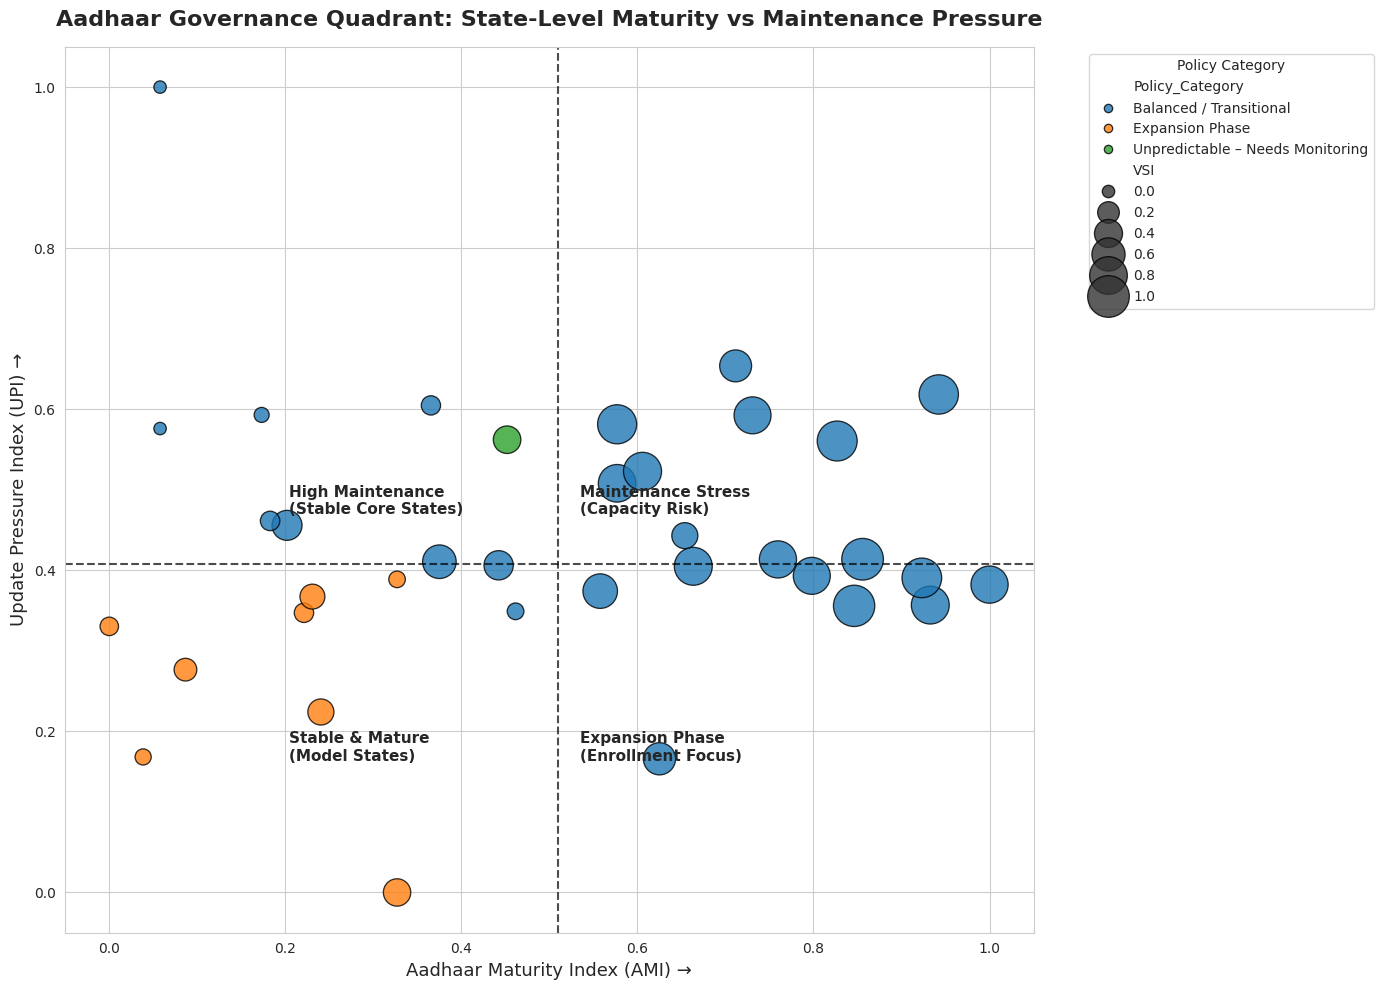

✅ Graph saved at: /content/drive/MyDrive/uidai/analysis/FIG_Governance_Quadrant_AMI_UPI.png
🎯 Aadhaar Governance Quadrant complete.


In [ ]:
# =========================================================
# GRAPH 1: AADHAAR GOVERNANCE QUADRANT (AMI vs UPI)
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("🔹 Creating Aadhaar Governance Quadrant (AMI vs UPI)")

# -------------------------------
# 1. Compute quadrant cut-offs
# -------------------------------
ami_mid = state_master["AMI"].median()
upi_mid = state_master["UPI"].median()

print(f"✔ AMI median (vertical split): {ami_mid:.2f}")
print(f"✔ UPI median (horizontal split): {upi_mid:.2f}")

# -------------------------------
# 2. Plot setup
# -------------------------------
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# -------------------------------
# 3. Scatter plot
# -------------------------------
scatter = sns.scatterplot(
    data=state_master,
    x="AMI",
    y="UPI",
    hue="Policy_Category",
    size="VSI",
    sizes=(80, 900),
    alpha=0.8,
    edgecolor="black"
)

# -------------------------------
# 4. Quadrant lines
# -------------------------------
plt.axvline(ami_mid, linestyle="--", color="black", alpha=0.7)
plt.axhline(upi_mid, linestyle="--", color="black", alpha=0.7)

# -------------------------------
# 5. Quadrant annotations
# -------------------------------
plt.text(
    ami_mid * 0.4, upi_mid * 1.15,
    "High Maintenance\n(Stable Core States)",
    fontsize=11, weight="bold"
)

plt.text(
    ami_mid * 1.05, upi_mid * 1.15,
    "Maintenance Stress\n(Capacity Risk)",
    fontsize=11, weight="bold"
)

plt.text(
    ami_mid * 0.4, upi_mid * 0.4,
    "Stable & Mature\n(Model States)",
    fontsize=11, weight="bold"
)

plt.text(
    ami_mid * 1.05, upi_mid * 0.4,
    "Expansion Phase\n(Enrollment Focus)",
    fontsize=11, weight="bold"
)

# -------------------------------
# 6. Title & labels
# -------------------------------
plt.title(
    "Aadhaar Governance Quadrant: State-Level Maturity vs Maintenance Pressure",
    fontsize=16,
    weight="bold",
    pad=15
)

plt.xlabel("Aadhaar Maturity Index (AMI) →", fontsize=13)
plt.ylabel("Update Pressure Index (UPI) →", fontsize=13)

# -------------------------------
# 7. Legend formatting
# -------------------------------
plt.legend(
    title="Policy Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# -------------------------------
# 8. Save output
# -------------------------------
output_path = "/content/drive/MyDrive/uidai/analysis/FIG_Governance_Quadrant_AMI_UPI.png"
plt.tight_layout()
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Graph saved at: {output_path}")
print("🎯 Aadhaar Governance Quadrant complete.")


In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# VSI Stress Diagnostic Graph
# -------------------------------

print("🔹 Creating VSI Stress Diagnostic (AMI vs VSI)")

fig, ax = plt.subplots(figsize=(12, 8))

# Color mapping for policy categories
color_map = {
    "Stable Mature System": "#2ca02c",
    "High Maintenance Stress": "#d62728",
    "Expansion Phase": "#ff7f0e",
    "Unpredictable – Needs Monitoring": "#9467bd",
    "Balanced / Transitional": "#1f77b4",
}

# Plot each policy category separately
for category, color in color_map.items():
    subset = state_master[state_master["Policy_Category"] == category]
    ax.scatter(
        subset["AMI"],
        subset["VSI"],
        s=300 * (subset["UPI"] + 0.2),   # bubble size = update pressure
        alpha=0.75,
        label=category,
        color=color,
        edgecolor="black",
        linewidth=0.6,
    )

# Median reference lines
ami_med = state_master["AMI"].median()
vsi_med = state_master["VSI"].median()

ax.axvline(ami_med, linestyle="--", color="gray", linewidth=1)
ax.axhline(vsi_med, linestyle="--", color="gray", linewidth=1)

# Quadrant annotations
ax.text(0.05, 0.9, "Expansion Volatility\n(Monitor Closely)",
        transform=ax.transAxes, fontsize=10)

ax.text(0.55, 0.9, "Mature but Fragile\n(Operational Risk)",
        transform=ax.transAxes, fontsize=10)

ax.text(0.05, 0.1, "Stable & Predictable\n(Model States)",
        transform=ax.transAxes, fontsize=10)

ax.text(0.55, 0.1, "High Pressure\n(Buffer Capacity Needed)",
        transform=ax.transAxes, fontsize=10)

# Labels and title
ax.set_xlabel("Aadhaar Maturity Index (AMI) →", fontsize=11)
ax.set_ylabel("Volatility Stress Index (VSI) →", fontsize=11)

ax.set_title(
    "VSI Stress Diagnostic: Identifying Operational Fragility in Aadhaar Governance",
    fontsize=14,
    fontweight="bold"
)

ax.legend(title="Policy Category", fontsize=9)
ax.grid(alpha=0.3)

# Save output
output_path = "/content/drive/MyDrive/uidai/analysis/FIG_VSI_Stress_Diagnostic.png"
plt.tight_layout()
plt.savefig(output_path, dpi=300)
plt.close()

print(f"✅ VSI Stress Diagnostic saved at:\n{output_path}")
print("🎯 Graph 2 complete.")


🔹 Creating VSI Stress Diagnostic (AMI vs VSI)
✅ VSI Stress Diagnostic saved at:
/content/drive/MyDrive/uidai/analysis/FIG_VSI_Stress_Diagnostic.png
🎯 Graph 2 complete.


🔹 Creating Rank Persistence Proof Graph


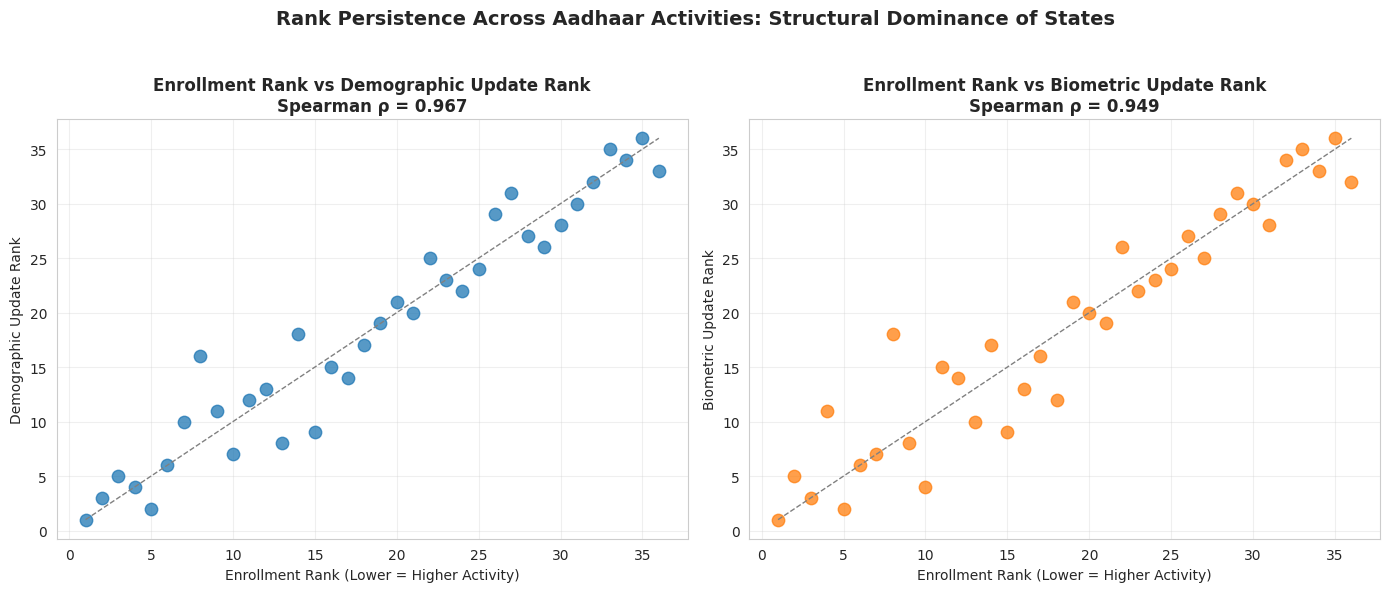

✅ Rank persistence graph saved at: /content/drive/MyDrive/uidai/analysis/FIG_Rank_Persistence_Proof.png
🎯 Rank hierarchy stability confirmed.


In [ ]:
# =========================================================
# RANK PERSISTENCE PROOF: ENROLLMENT vs UPDATES
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

print("🔹 Creating Rank Persistence Proof Graph")

# Compute Spearman correlations (for annotation)
rho_ED, _ = spearmanr(state_master["E_rank"], state_master["D_rank"])
rho_EB, _ = spearmanr(state_master["E_rank"], state_master["B_rank"])

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------------------------------------
# Plot 1: Enrollment Rank vs Demographic Update Rank
axes[0].scatter(
    state_master["E_rank"],
    state_master["D_rank"],
    alpha=0.75,
    s=80,
    color="#1f77b4"
)

# Perfect rank line
axes[0].plot(
    [1, state_master.shape[0]],
    [1, state_master.shape[0]],
    linestyle="--",
    color="gray",
    linewidth=1
)

axes[0].set_title(
    f"Enrollment Rank vs Demographic Update Rank\nSpearman ρ = {rho_ED:.3f}",
    fontweight="bold"
)
axes[0].set_xlabel("Enrollment Rank (Lower = Higher Activity)")
axes[0].set_ylabel("Demographic Update Rank")
axes[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# Plot 2: Enrollment Rank vs Biometric Update Rank
axes[1].scatter(
    state_master["E_rank"],
    state_master["B_rank"],
    alpha=0.75,
    s=80,
    color="#ff7f0e"
)

# Perfect rank line
axes[1].plot(
    [1, state_master.shape[0]],
    [1, state_master.shape[0]],
    linestyle="--",
    color="gray",
    linewidth=1
)

axes[1].set_title(
    f"Enrollment Rank vs Biometric Update Rank\nSpearman ρ = {rho_EB:.3f}",
    fontweight="bold"
)
axes[1].set_xlabel("Enrollment Rank (Lower = Higher Activity)")
axes[1].set_ylabel("Biometric Update Rank")
axes[1].grid(True, alpha=0.3)

# ---------------------------------------------------------
plt.suptitle(
    "Rank Persistence Across Aadhaar Activities: Structural Dominance of States",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save
output_path = "/content/drive/MyDrive/uidai/analysis/FIG_Rank_Persistence_Proof.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Rank persistence graph saved at: {output_path}")
print("🎯 Rank hierarchy stability confirmed.")


In [ ]:
# =========================================================
# GRAPH: Volatility vs Total Aadhaar Activity
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

print("🔹 Creating Volatility vs Total Activity Diagnostic")

# Compute total Aadhaar activity
state_master["Total_Activity"] = (
    state_master["E_total"] +
    state_master["D_total"] +
    state_master["B_total"]
)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    np.log1p(state_master["Total_Activity"]),
    state_master["VSI"],
    s=300 * state_master["UPI"],          # bubble size = pressure
    c=state_master["AMI"],                # color = maturity
    cmap="viridis",
    alpha=0.75,
    edgecolor="black"
)

# Reference lines (medians)
plt.axhline(state_master["VSI"].median(), linestyle="--", color="gray", alpha=0.6)
plt.axvline(np.log1p(state_master["Total_Activity"]).median(),
            linestyle="--", color="gray", alpha=0.6)

plt.colorbar(scatter, label="Aadhaar Maturity Index (AMI)")

plt.xlabel("Log(Total Aadhaar Activity)")
plt.ylabel("Volatility Stress Index (VSI)")
plt.title(
    "Operational Stress Diagnostic:\nVolatility vs Aadhaar Activity Load",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.tight_layout()

output_path = "/content/drive/MyDrive/uidai/analysis/FIG_Volatility_vs_Activity.png"
plt.savefig(output_path, dpi=300)
plt.close()

print(f"✅ Graph saved: {output_path}")


🔹 Creating Volatility vs Total Activity Diagnostic
✅ Graph saved: /content/drive/MyDrive/uidai/analysis/FIG_Volatility_vs_Activity.png


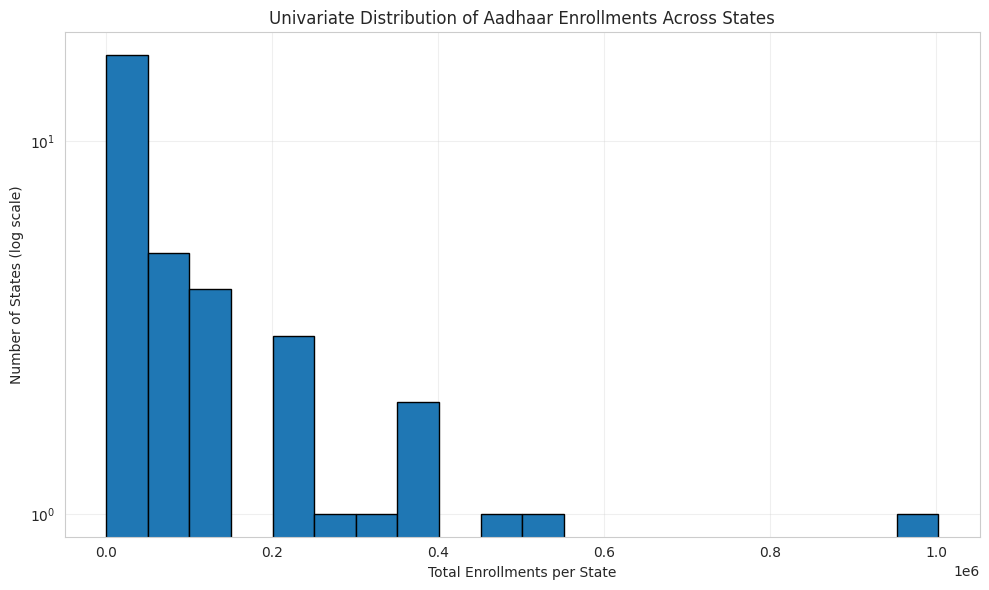

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

plt.hist(
    state_master["E_total"],
    bins=20,
    log=True,
    edgecolor="black"
)

plt.xlabel("Total Enrollments per State")
plt.ylabel("Number of States (log scale)")
plt.title("Univariate Distribution of Aadhaar Enrollments Across States")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


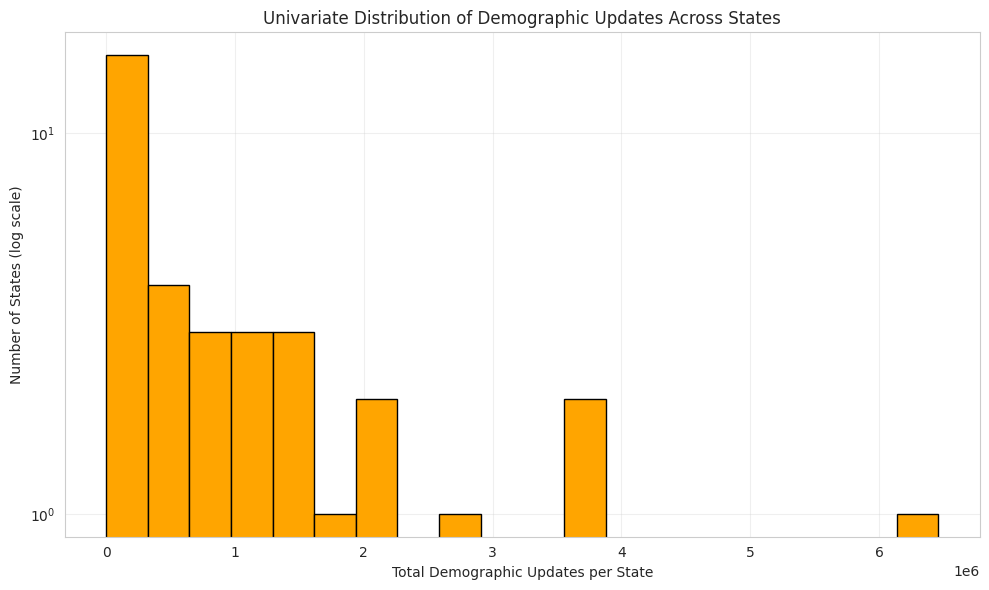

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    state_master["D_total"],
    bins=20,
    log=True,
    edgecolor="black",
    color="orange"
)

plt.xlabel("Total Demographic Updates per State")
plt.ylabel("Number of States (log scale)")
plt.title("Univariate Distribution of Demographic Updates Across States")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


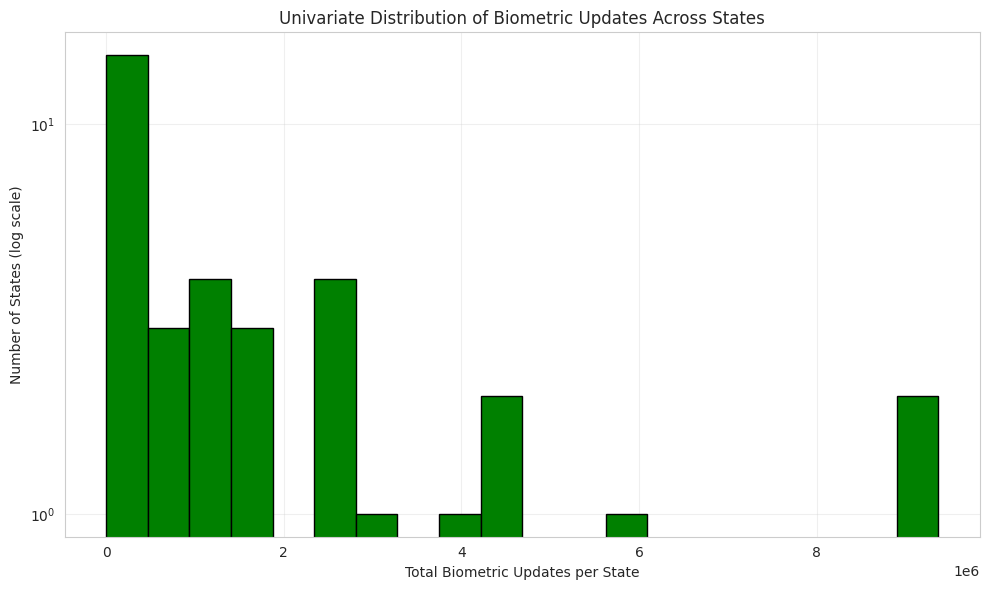

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    state_master["B_total"],
    bins=20,
    log=True,
    edgecolor="black",
    color="green"
)

plt.xlabel("Total Biometric Updates per State")
plt.ylabel("Number of States (log scale)")
plt.title("Univariate Distribution of Biometric Updates Across States")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


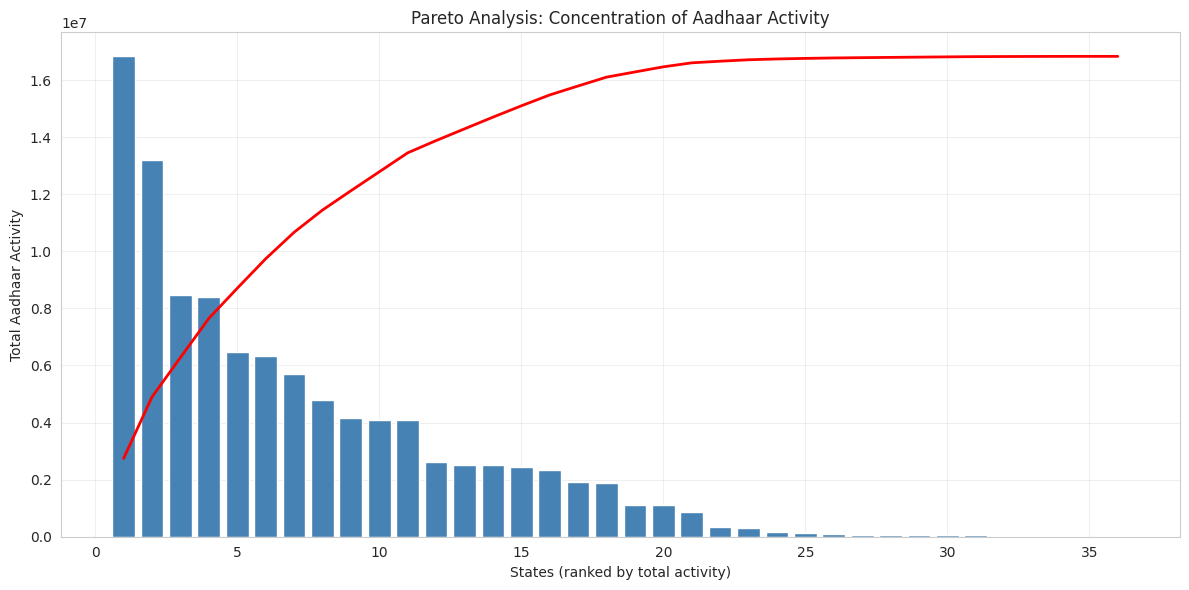

In [ ]:
state_master["Total_Activity"] = (
    state_master["E_total"] +
    state_master["D_total"] +
    state_master["B_total"]
)

pareto_df = (
    state_master
    .sort_values("Total_Activity", ascending=False)
    .reset_index(drop=True)
)

pareto_df["cum_share"] = (
    pareto_df["Total_Activity"].cumsum()
    / pareto_df["Total_Activity"].sum()
)

plt.figure(figsize=(12,6))

plt.bar(
    pareto_df.index + 1,
    pareto_df["Total_Activity"],
    color="steelblue"
)

plt.plot(
    pareto_df.index + 1,
    pareto_df["cum_share"] * pareto_df["Total_Activity"].max(),
    color="red",
    linewidth=2
)

plt.xlabel("States (ranked by total activity)")
plt.ylabel("Total Aadhaar Activity")
plt.title("Pareto Analysis: Concentration of Aadhaar Activity")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


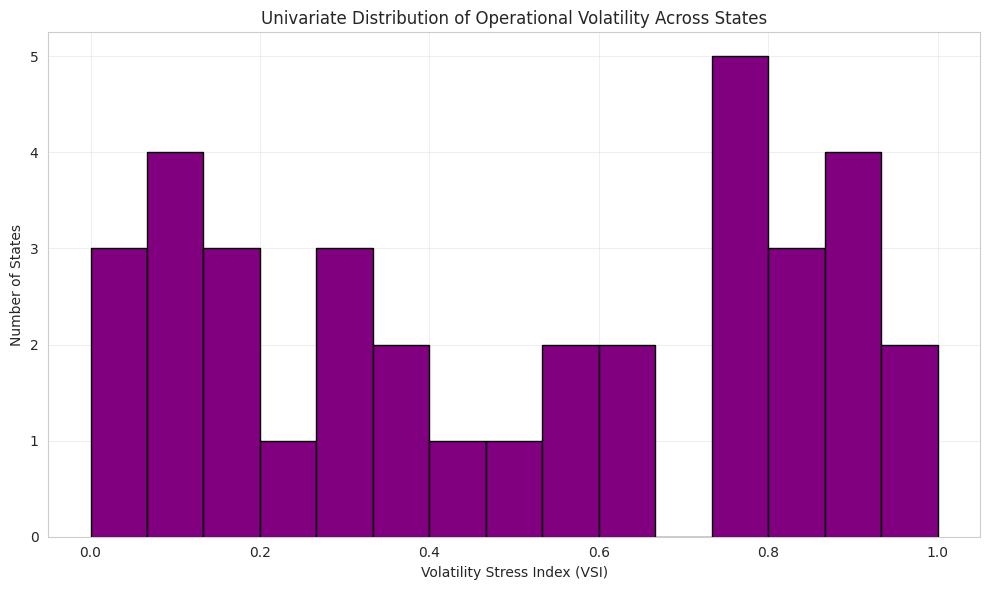

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    state_master["VSI"],
    bins=15,
    edgecolor="black",
    color="purple"
)

plt.xlabel("Volatility Stress Index (VSI)")
plt.ylabel("Number of States")
plt.title("Univariate Distribution of Operational Volatility Across States")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


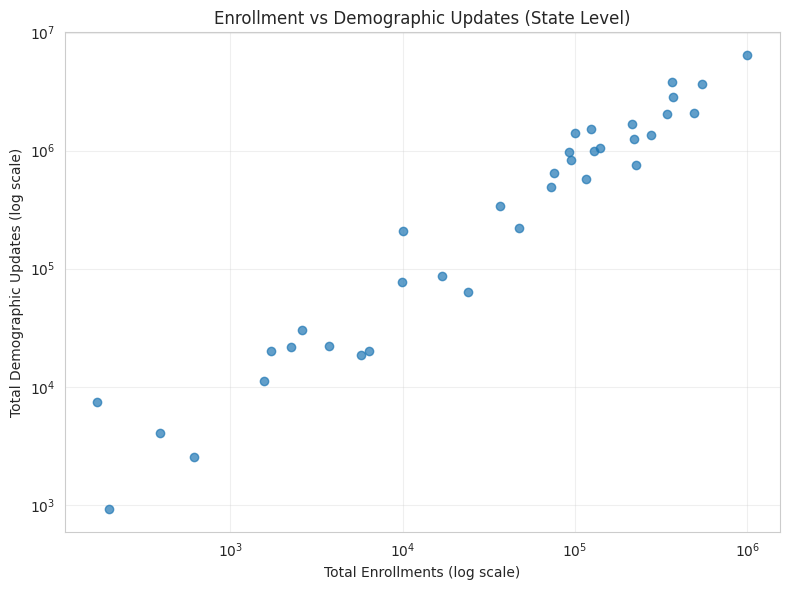

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(
    state_master["E_total"],
    state_master["D_total"],
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Total Enrollments (log scale)")
plt.ylabel("Total Demographic Updates (log scale)")
plt.title("Enrollment vs Demographic Updates (State Level)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


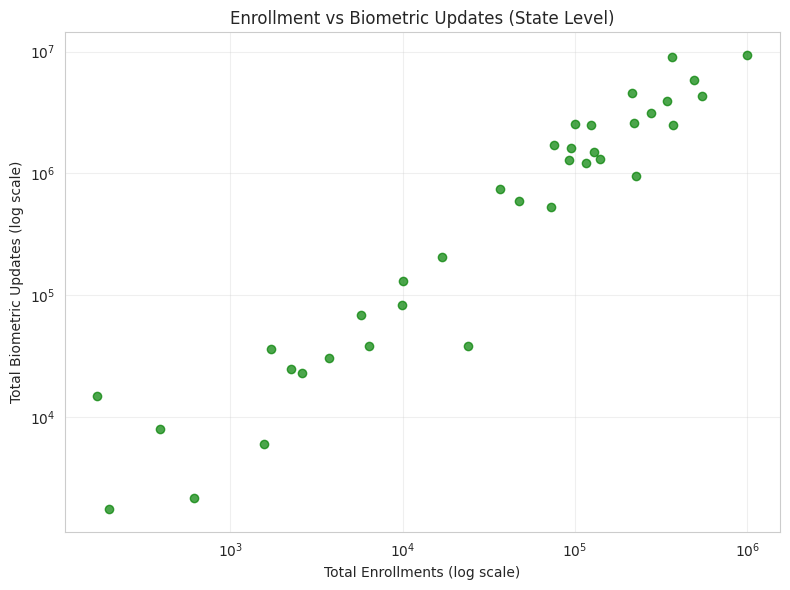

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    state_master["E_total"],
    state_master["B_total"],
    alpha=0.7,
    color="green"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Total Enrollments (log scale)")
plt.ylabel("Total Biometric Updates (log scale)")
plt.title("Enrollment vs Biometric Updates (State Level)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


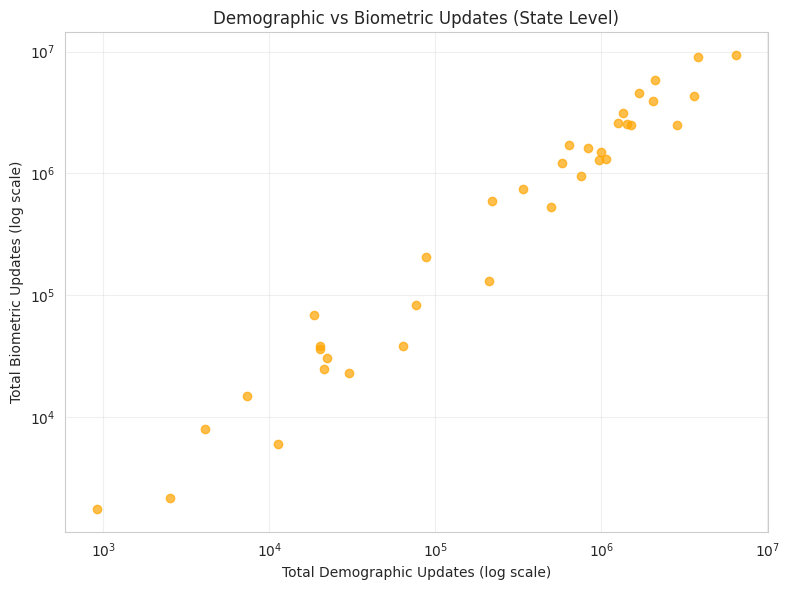

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    state_master["D_total"],
    state_master["B_total"],
    alpha=0.7,
    color="orange"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Total Demographic Updates (log scale)")
plt.ylabel("Total Biometric Updates (log scale)")
plt.title("Demographic vs Biometric Updates (State Level)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


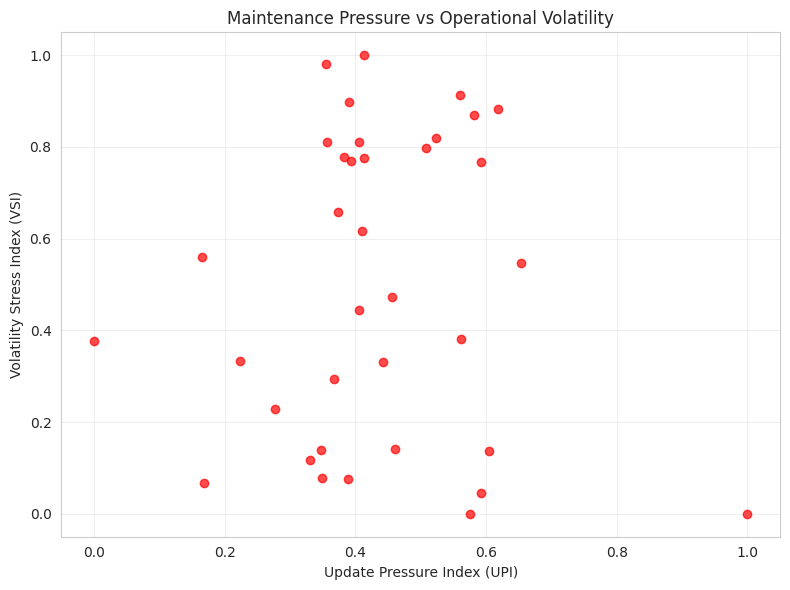

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    state_master["UPI"],
    state_master["VSI"],
    alpha=0.7,
    color="red"
)

plt.xlabel("Update Pressure Index (UPI)")
plt.ylabel("Volatility Stress Index (VSI)")
plt.title("Maintenance Pressure vs Operational Volatility")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


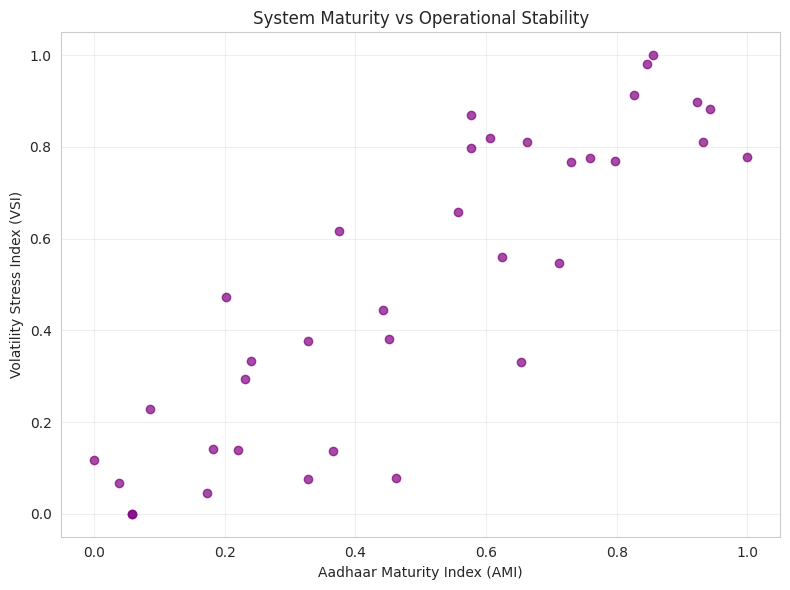

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    state_master["AMI"],
    state_master["VSI"],
    alpha=0.7,
    color="purple"
)

plt.xlabel("Aadhaar Maturity Index (AMI)")
plt.ylabel("Volatility Stress Index (VSI)")
plt.title("System Maturity vs Operational Stability")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


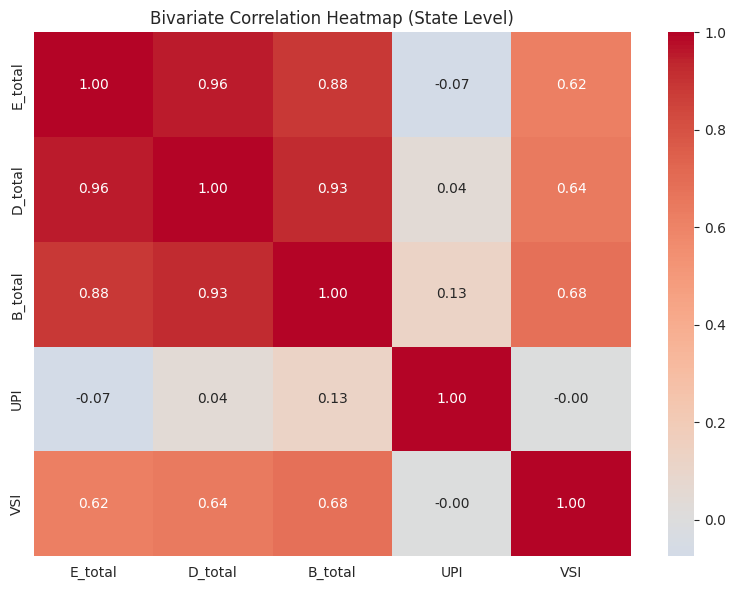

In [ ]:
import seaborn as sns

corr_cols = [
    "E_total",
    "D_total",
    "B_total",
    "UPI",
    "VSI"
]

corr_matrix = state_master[corr_cols].corr(method="pearson")

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Bivariate Correlation Heatmap (State Level)")
plt.tight_layout()
plt.show()


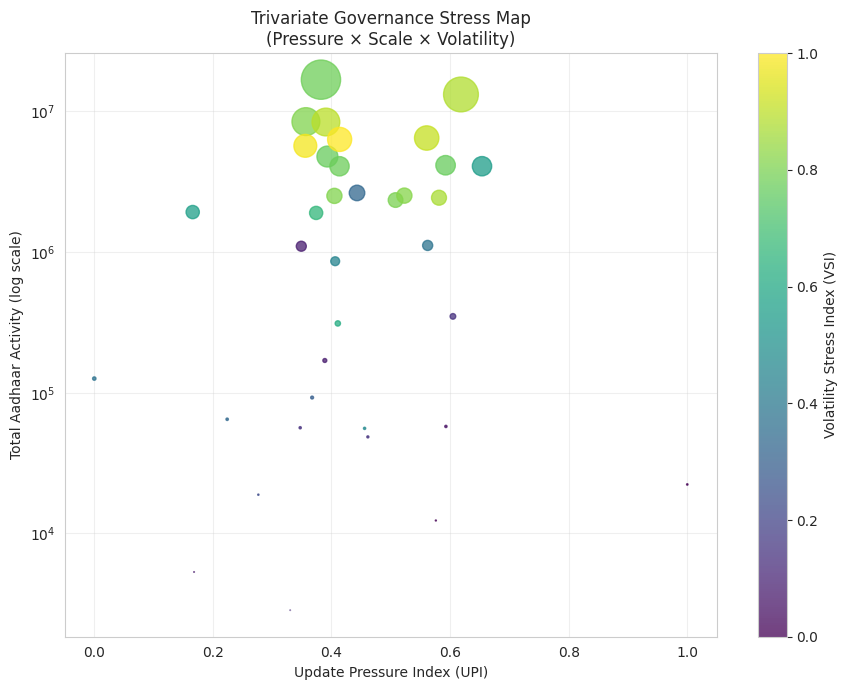

In [ ]:
import matplotlib.pyplot as plt

# Compute total Aadhaar activity
state_master["Total_Activity"] = (
    state_master["E_total"] +
    state_master["D_total"] +
    state_master["B_total"]
)

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    state_master["UPI"],
    state_master["Total_Activity"],
    s = state_master["Total_Activity"] / state_master["Total_Activity"].max() * 800,
    c = state_master["VSI"],
    cmap="viridis",
    alpha=0.75
)

plt.yscale("log")

plt.xlabel("Update Pressure Index (UPI)")
plt.ylabel("Total Aadhaar Activity (log scale)")
plt.title("Trivariate Governance Stress Map\n(Pressure × Scale × Volatility)")

cbar = plt.colorbar(scatter)
cbar.set_label("Volatility Stress Index (VSI)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,7))

plt.scatter(
    state_master["E_child_share"],
    state_master["D_adult_share"],
    s = state_master["Total_Activity"] / state_master["Total_Activity"].max() * 800,
    alpha=0.7
)

plt.xlabel("Child Enrollment Share (0–5)")
plt.ylabel("Adult Demographic Update Share (17+)")
plt.title("Lifecycle Transition Pattern\n(Enrollment Age vs Update Age)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print(state_month.columns)
state_month.head()


Index(['state', 'year_month', 'E_total', 'E_0_5', 'E_5_17', 'E_18_plus',
       'D_total', 'D_5_17', 'D_17_plus', 'B_total', 'B_5_17', 'B_17_plus',
       'update_to_enrol_ratio', 'E_child_share', 'D_adult_share',
       'B_adult_share'],
      dtype='object')


,state,year_month,E_total,E_0_5,E_5_17,E_18_plus,D_total,D_5_17,D_17_plus,B_total,B_5_17,B_17_plus,update_to_enrol_ratio,E_child_share,D_adult_share,B_adult_share
0,Andaman And Nicobar Islands,2025-09,145,133,12,0,790,61,729,2642,1733,909,23.668965,0.082759,0.922785,0.344058
1,Andaman And Nicobar Islands,2025-10,60,52,8,0,550,61,489,1300,808,492,30.833333,0.133333,0.889091,0.378462
2,Andaman And Nicobar Islands,2025-11,88,85,3,0,1155,105,1050,1641,1052,589,31.772727,0.034091,0.909091,0.358927
3,Andaman And Nicobar Islands,2025-12,97,93,4,0,1583,122,1461,2297,1597,700,40.000000,0.041237,0.922931,0.304745
4,Andhra Pradesh,2025-03,116,43,44,29,370695,34912,335783,403296,243777,159519,6672.336149,0.379310,0.905820,0.395538


In [ ]:
state_month_df = state_month.copy()


In [ ]:
import numpy as np

state_month_df["E_child_share"] = (
    state_month_df["E_0_5"] / state_month_df["E_total"]
).replace([np.inf, -np.inf], np.nan)

state_month_df["D_adult_share"] = (
    state_month_df["D_17_plus"] / state_month_df["D_total"]
).replace([np.inf, -np.inf], np.nan)

state_month_df["B_adult_share"] = (
    state_month_df["B_17_plus"] / state_month_df["B_total"]
).replace([np.inf, -np.inf], np.nan)

print("✔ Age-share features created at state–month level")
state_month_df[
    ["state", "year_month", "E_child_share", "D_adult_share", "B_adult_share"]
].head()


✔ Age-share features created at state–month level


,state,year_month,E_child_share,D_adult_share,B_adult_share
0,Andaman And Nicobar Islands,2025-09,0.917241,0.922785,0.344058
1,Andaman And Nicobar Islands,2025-10,0.866667,0.889091,0.378462
2,Andaman And Nicobar Islands,2025-11,0.965909,0.909091,0.358927
3,Andaman And Nicobar Islands,2025-12,0.958763,0.922931,0.304745
4,Andhra Pradesh,2025-03,0.370690,0.905820,0.395538


In [ ]:
state_master = (
    state_month_df
    .groupby("state", as_index=False)
    .agg(
        E_total=("E_total", "sum"),
        D_total=("D_total", "sum"),
        B_total=("B_total", "sum"),
        E_child_share=("E_child_share", "mean"),
        D_adult_share=("D_adult_share", "mean"),
        B_adult_share=("B_adult_share", "mean"),
    )
)

state_master["Total_Activity"] = (
    state_master["E_total"] +
    state_master["D_total"] +
    state_master["B_total"]
)

print("✔ State-level totals + lifecycle shares ready")
state_master.head()


✔ State-level totals + lifecycle shares ready


,state,E_total,D_total,B_total,E_child_share,D_adult_share,B_adult_share,Total_Activity
0,Andaman And Nicobar Islands,390,4078,7880,0.927145,0.910974,0.346548,12348
1,Andhra Pradesh,124272,1518607,2501526,0.717230,0.855000,0.463661,4144405
2,Arunachal Pradesh,3756,22226,30399,0.504279,0.824472,0.273051,56381
3,Assam,225359,755097,945150,0.543660,0.910914,0.394479,1925606
4,Bihar,547367,3638841,4284511,0.402300,0.913564,0.562929,8470719


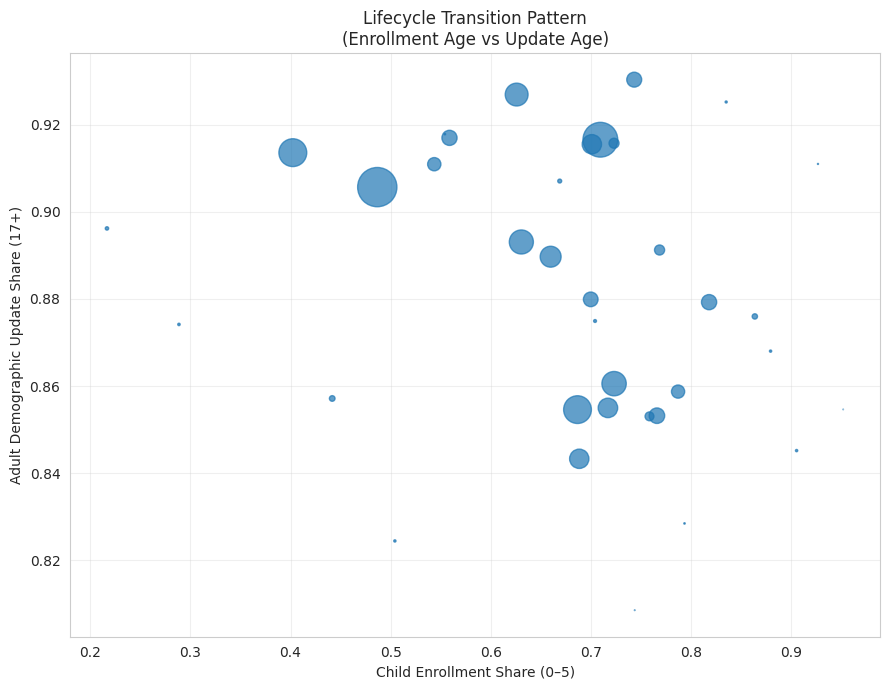

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))

plt.scatter(
    state_master["E_child_share"],
    state_master["D_adult_share"],
    s = state_master["Total_Activity"] / state_master["Total_Activity"].max() * 800,
    alpha=0.7
)

plt.xlabel("Child Enrollment Share (0–5)")
plt.ylabel("Adult Demographic Update Share (17+)")
plt.title("Lifecycle Transition Pattern\n(Enrollment Age vs Update Age)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
state_master[["E_child_share", "D_adult_share"]].describe()


,E_child_share,D_adult_share
count,36.000000,36.000000
mean,0.680062,0.881460
std,0.168194,0.032411
min,0.216550,0.808582
25%,0.609221,0.854911
50%,0.707001,0.879583
75%,0.773457,0.911622
max,0.952344,0.930313


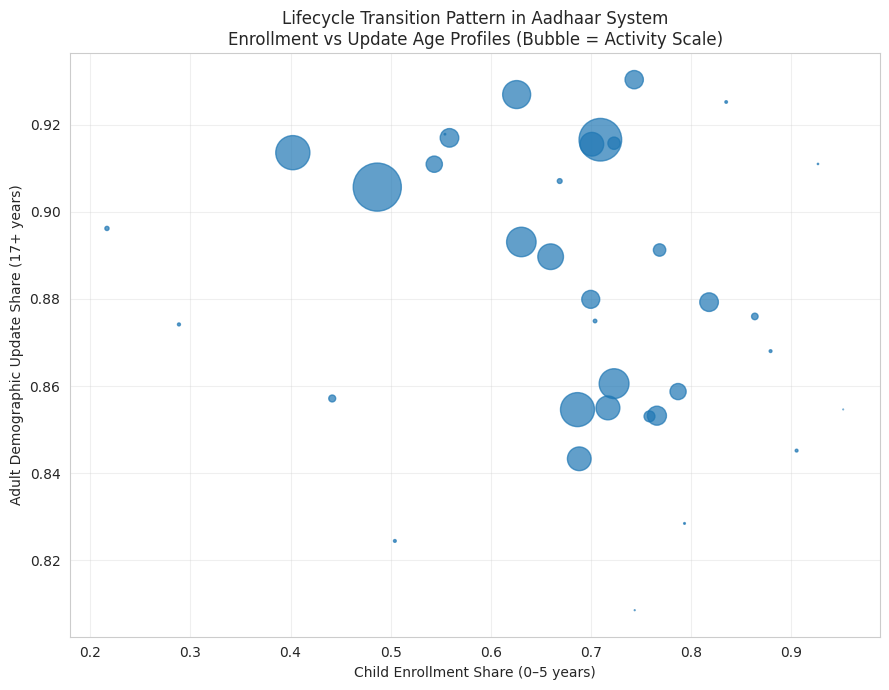

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))

plt.scatter(
    state_master["E_child_share"],
    state_master["D_adult_share"],
    s = (
        state_master["Total_Activity"]
        / state_master["Total_Activity"].max()
    ) * 1200,
    alpha=0.7
)

plt.xlabel("Child Enrollment Share (0–5 years)")
plt.ylabel("Adult Demographic Update Share (17+ years)")
plt.title(
    "Lifecycle Transition Pattern in Aadhaar System\n"
    "Enrollment vs Update Age Profiles (Bubble = Activity Scale)"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# -------------------------------
# REBUILD INDICATOR TABLE
# -------------------------------

import numpy as np
from sklearn.preprocessing import MinMaxScaler

state_indicators = (
    state_month
    .groupby("state", as_index=False)
    .agg(
        E_total=("E_total", "sum"),
        D_total=("D_total", "sum"),
        B_total=("B_total", "sum"),
    )
)

# Ranks for AMI
state_indicators["E_rank"] = state_indicators["E_total"].rank(ascending=False)
state_indicators["D_rank"] = state_indicators["D_total"].rank(ascending=False)
state_indicators["B_rank"] = state_indicators["B_total"].rank(ascending=False)

state_indicators["AMI_raw"] = (
    state_indicators["E_rank"] +
    state_indicators["D_rank"] +
    state_indicators["B_rank"]
)

# UPI (log-stabilized)
state_indicators["UPI_raw"] = (
    np.log1p(state_indicators["D_total"] + state_indicators["B_total"])
    - np.log1p(state_indicators["E_total"])
)


In [ ]:
# Merge volatility
state_indicators = state_indicators.merge(
    cv_df[["state", "ratio_cv"]],
    on="state",
    how="left"
).rename(columns={"ratio_cv": "VSI_raw"})

# Merge lag correlation
state_indicators = state_indicators.merge(
    lag_corr_df[["state", "lag1_corr"]],
    on="state",
    how="left"
)

state_indicators["TPS_raw"] = state_indicators["lag1_corr"].abs()


NameError: name 'cv_df' is not defined

In [ ]:
print(state_stability.head())
print(state_stability.columns)


                         state      E_cv      D_cv      B_cv  ratio_cv
0  Andaman And Nicobar Islands  0.362764  0.441935  0.309555  0.211766
1               Andhra Pradesh  0.946968  0.549690  0.248149  2.297616
2            Arunachal Pradesh  0.632623  0.414006  0.194430  0.590984
3                        Assam  0.648157  0.901088  0.237396  1.731302
4                        Bihar  0.675550  0.877890  0.370466  2.417712
Index(['state', 'E_cv', 'D_cv', 'B_cv', 'ratio_cv'], dtype='object')


In [ ]:
state_indicators = state_indicators.merge(
    state_stability[["state", "ratio_cv"]],
    on="state",
    how="left"
)

state_indicators.rename(columns={"ratio_cv": "VSI_raw"}, inplace=True)


In [ ]:
print(state_indicators.columns.tolist())


['state', 'E_total', 'D_total', 'B_total', 'E_rank', 'D_rank', 'B_rank', 'AMI_raw', 'UPI_raw', 'VSI_raw']


In [ ]:
# Merge lag correlation → TPS_raw
state_indicators = state_indicators.merge(
    lag_df[["state", "lag1_corr"]],
    on="state",
    how="left"
)

state_indicators["TPS_raw"] = state_indicators["lag1_corr"].abs()
state_indicators.drop(columns=["lag1_corr"], inplace=True)

print("✔ TPS_raw merged")
print(state_indicators[["state", "TPS_raw"]].head())


✔ TPS_raw merged
                         state   TPS_raw
0  Andaman And Nicobar Islands  0.999682
1               Andhra Pradesh  0.527897
2            Arunachal Pradesh  0.909199
3                        Assam  0.429464
4                        Bihar  0.749690


In [ ]:
print(state_indicators.columns.tolist())


['state', 'E_total', 'D_total', 'B_total', 'E_rank', 'D_rank', 'B_rank', 'AMI_raw', 'UPI_raw', 'VSI_raw', 'TPS_raw']


In [ ]:
from sklearn.preprocessing import MinMaxScaler

print("🔹 Step 2: Normalizing indicators (jury-safe form)")

scaler = MinMaxScaler()

indicator_cols = ["AMI_raw", "UPI_raw", "VSI_raw", "TPS_raw"]

state_indicators[indicator_cols] = scaler.fit_transform(
    state_indicators[indicator_cols]
)

state_indicators.rename(columns={
    "AMI_raw": "AMI",
    "UPI_raw": "UPI",
    "VSI_raw": "VSI",
    "TPS_raw": "TPS"
}, inplace=True)

print("✔ Indicators normalized to [0,1]")
print(state_indicators[["state", "AMI", "UPI", "VSI", "TPS"]].head())


🔹 Step 2: Normalizing indicators (jury-safe form)
✔ Indicators normalized to [0,1]
                         state       AMI       UPI       VSI       TPS
0  Andaman And Nicobar Islands  0.942308  0.576001  0.000199  1.000000
1               Andhra Pradesh  0.269231  0.592423  0.767389  0.495126
2            Arunachal Pradesh  0.778846  0.347235  0.139678  0.903171
3                        Assam  0.375000  0.165978  0.559095  0.389789
4                        Bihar  0.067308  0.356861  0.811561  0.732475


In [ ]:
print("🔹 Step 3: Computing Total Aadhaar Activity")

state_indicators["Total_Activity"] = (
    state_indicators["E_total"] +
    state_indicators["D_total"] +
    state_indicators["B_total"]
)

print("✔ Total_Activity created")
print(state_indicators[["state", "Total_Activity"]].head())


🔹 Step 3: Computing Total Aadhaar Activity
✔ Total_Activity created
                         state  Total_Activity
0  Andaman And Nicobar Islands           12348
1               Andhra Pradesh         4144405
2            Arunachal Pradesh           56381
3                        Assam         1925606
4                        Bihar         8470719


In [ ]:
print(state_indicators.columns.tolist())


['state', 'E_total', 'D_total', 'B_total', 'E_rank', 'D_rank', 'B_rank', 'AMI', 'UPI', 'VSI', 'TPS', 'Total_Activity']


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("🔹 Preparing indicator correlation matrix")

indicator_df = state_indicators[
    ["AMI", "UPI", "VSI", "TPS"]
].copy()

corr_matrix = indicator_df.corr(method="pearson")

print("✔ Correlation matrix computed")
corr_matrix


🔹 Preparing indicator correlation matrix
✔ Correlation matrix computed


,AMI,UPI,VSI,TPS
AMI,1.000000,-0.044618,-0.868526,0.154794
UPI,-0.044618,1.000000,-0.002034,-0.128141
VSI,-0.868526,-0.002034,1.000000,-0.071081
TPS,0.154794,-0.128141,-0.071081,1.000000


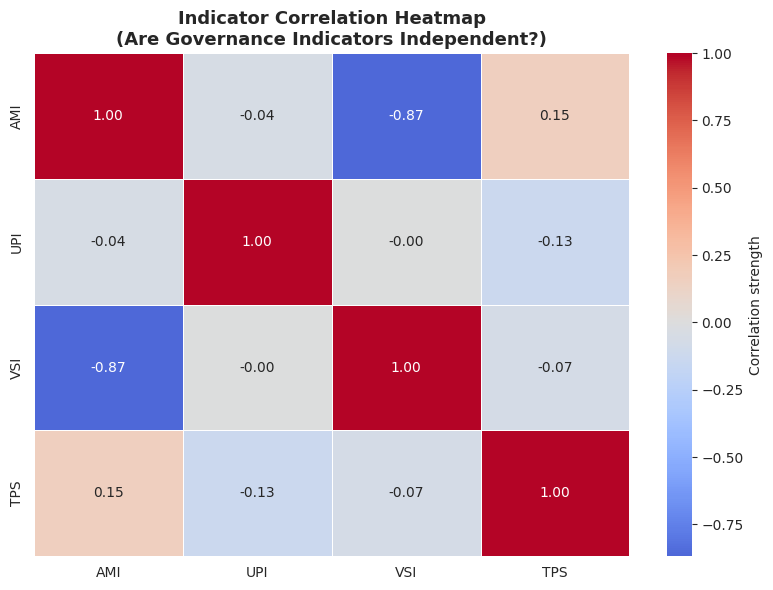

✅ Heatmap saved at: /content/drive/MyDrive/uidai/analysis/FIG_Indicator_Correlation_Heatmap.png


In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation strength"}
)

plt.title(
    "Indicator Correlation Heatmap\n"
    "(Are Governance Indicators Independent?)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

output_path = "/content/drive/MyDrive/uidai/analysis/FIG_Indicator_Correlation_Heatmap.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Heatmap saved at: {output_path}")


In [ ]:
print(state_indicators.columns.tolist())


['state', 'E_total', 'D_total', 'B_total', 'E_rank', 'D_rank', 'B_rank', 'AMI', 'UPI', 'VSI', 'TPS', 'Total_Activity']


In [ ]:
print("🔹 Computing Total Aadhaar Activity (scale proxy)")

state_indicators = state_indicators.copy()

state_indicators["Total_Activity"] = (
    state_indicators["E_total"] +
    state_indicators["D_total"] +
    state_indicators["B_total"]
)

print("✔ Total Activity computed")
state_indicators[["state", "Total_Activity", "VSI"]].head()


🔹 Computing Total Aadhaar Activity (scale proxy)
✔ Total Activity computed


,state,Total_Activity,VSI
0,Andaman And Nicobar Islands,12348,0.000199
1,Andhra Pradesh,4144405,0.767389
2,Arunachal Pradesh,56381,0.139678
3,Assam,1925606,0.559095
4,Bihar,8470719,0.811561


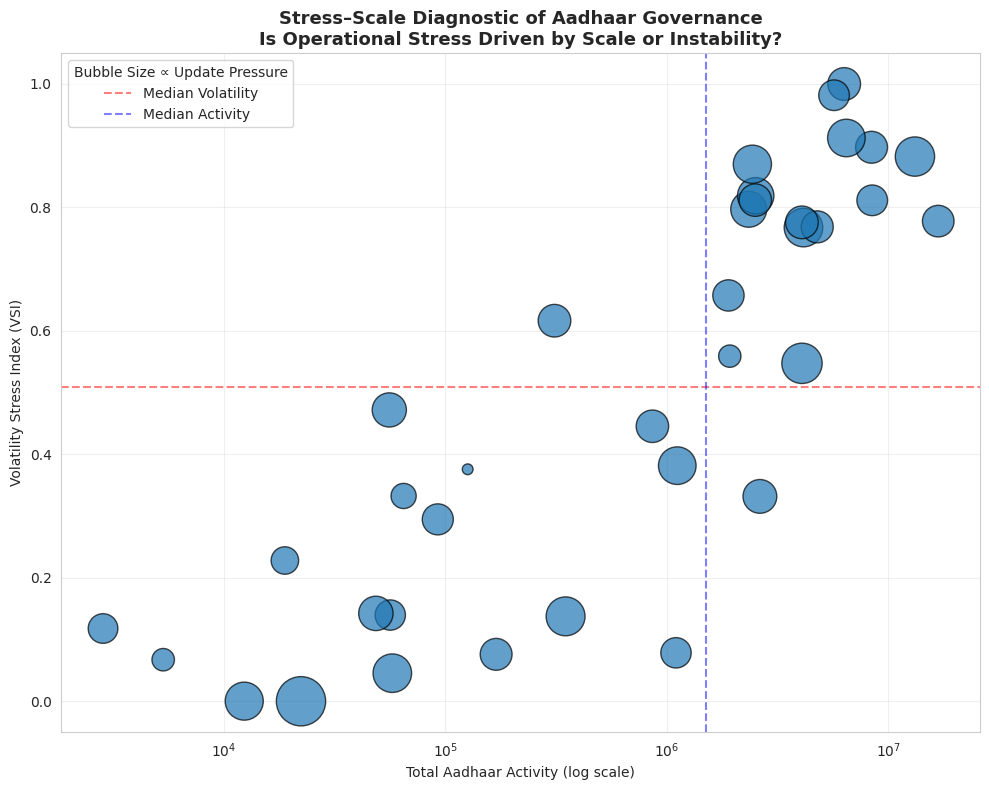

✅ Stress–Scale diagnostic saved at: /content/drive/MyDrive/uidai/analysis/FIG_Stress_vs_Scale.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

plt.scatter(
    state_indicators["Total_Activity"],
    state_indicators["VSI"],
    s = (state_indicators["UPI"] + 0.05) * 1200,  # bubble = maintenance pressure
    alpha=0.7,
    edgecolor="black"
)

plt.xscale("log")

plt.xlabel("Total Aadhaar Activity (log scale)")
plt.ylabel("Volatility Stress Index (VSI)")
plt.title(
    "Stress–Scale Diagnostic of Aadhaar Governance\n"
    "Is Operational Stress Driven by Scale or Instability?",
    fontsize=13,
    fontweight="bold"
)

plt.grid(alpha=0.3)

# Median reference lines
plt.axhline(
    state_indicators["VSI"].median(),
    linestyle="--",
    color="red",
    alpha=0.5,
    label="Median Volatility"
)

plt.axvline(
    state_indicators["Total_Activity"].median(),
    linestyle="--",
    color="blue",
    alpha=0.5,
    label="Median Activity"
)

plt.legend(title="Bubble Size ∝ Update Pressure")

plt.tight_layout()

output_path = "/content/drive/MyDrive/uidai/analysis/FIG_Stress_vs_Scale.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Stress–Scale diagnostic saved at: {output_path}")


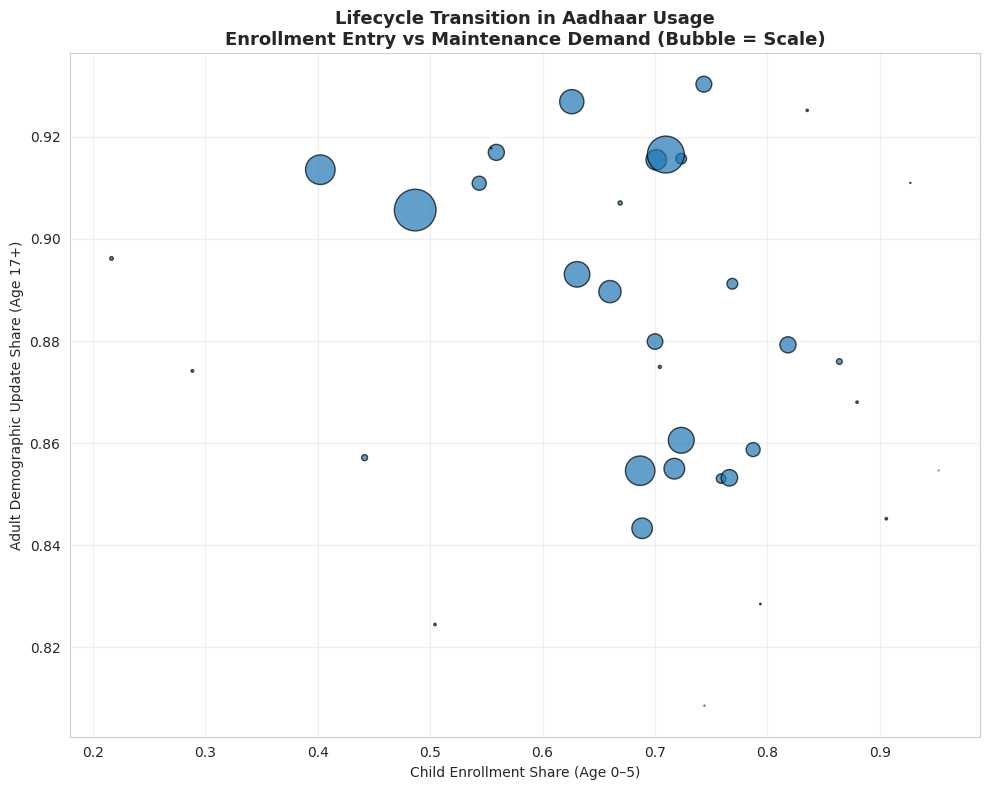

✅ Trivariate lifecycle graph saved at: /content/drive/MyDrive/uidai/analysis/FIG_Lifecycle_Trivariate.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

plt.scatter(
    state_master["E_child_share"],              # X: early lifecycle entry
    state_master["D_adult_share"],              # Y: adult maintenance
    s = state_master["Total_Activity"]
        / state_master["Total_Activity"].max() * 900,  # size = scale
    alpha=0.7,
    edgecolor="black"
)

plt.xlabel("Child Enrollment Share (Age 0–5)")
plt.ylabel("Adult Demographic Update Share (Age 17+)")
plt.title(
    "Lifecycle Transition in Aadhaar Usage\n"
    "Enrollment Entry vs Maintenance Demand (Bubble = Scale)",
    fontsize=13,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.tight_layout()

output_path = "/content/drive/MyDrive/uidai/analysis/FIG_Lifecycle_Trivariate.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Trivariate lifecycle graph saved at: {output_path}")


In [ ]:
corr = state_master["E_child_share"].corr(
    state_master["D_adult_share"]
)

print(f"Lifecycle correlation (child enrollment vs adult updates): {corr:.3f}")


Lifecycle correlation (child enrollment vs adult updates): -0.192


In [ ]:
print(state_master.columns.tolist())


['state', 'E_total', 'D_total', 'B_total', 'E_child_share', 'D_adult_share', 'B_adult_share', 'Total_Activity']


In [ ]:
print("Object name:", id(state_master))
print("Columns:", state_master.columns.tolist())


Object name: 136553810888704
Columns: ['state', 'E_total', 'D_total', 'B_total', 'E_child_share', 'D_adult_share', 'B_adult_share', 'Total_Activity']


In [ ]:
import pandas as pd

print("🔍 Merging normalized indicators into state_master...")

# Ensure state_master has the 'state' column to merge on
# Select only the relevant indicator columns from state_indicators
indicators_to_merge = state_indicators[['state', 'AMI', 'UPI', 'VSI', 'TPS']].copy()

# Merge state_master with the normalized indicators from state_indicators
state_master = state_master.merge(
    indicators_to_merge,
    on='state',
    how='left'
)

print("✅ Merging successful. state_master now contains AMI, UPI, VSI, TPS.")
print(state_master[['state', 'AMI', 'UPI', 'VSI', 'TPS']].head())

🔍 Merging normalized indicators into state_master...
✅ Merging successful. state_master now contains AMI, UPI, VSI, TPS.
                         state       AMI       UPI       VSI       TPS
0  Andaman And Nicobar Islands  0.942308  0.576001  0.000199  1.000000
1               Andhra Pradesh  0.269231  0.592423  0.767389  0.495126
2            Arunachal Pradesh  0.778846  0.347235  0.139678  0.903171
3                        Assam  0.375000  0.165978  0.559095  0.389789
4                        Bihar  0.067308  0.356861  0.811561  0.732475


In [ ]:
assert all(c in state_master.columns for c in ["AMI","UPI","VSI","TPS"])
print("✅ AMI, UPI, VSI, TPS confirmed present")


✅ AMI, UPI, VSI, TPS confirmed present


In [ ]:
def map_policy_action(row):

    if row["AMI"] < 0.3 and row["VSI"] < 0.3:
        return (
            "Stable Mature System",
            "Maintain baseline infrastructure; prioritize service quality audits"
        )

    if row["UPI"] > 0.7 and row["VSI"] > 0.7:
        return (
            "High Maintenance Stress",
            "Deploy update-only centers; surge staffing; decentralize services"
        )

    if row["AMI"] > 0.7 and row["UPI"] < 0.4:
        return (
            "Expansion Phase",
            "Expand enrollment through mobile units and institutional drives"
        )

    if row["TPS"] < 0.3:
        return (
            "Unpredictable – Monitoring Required",
            "Implement monthly monitoring with flexible staffing buffers"
        )

    return (
        "Balanced / Transitional",
        "Maintain mixed enrollment–update strategy"
    )


In [ ]:
state_master[["Governance_Status","Policy_Action"]] = (
    state_master.apply(map_policy_action, axis=1, result_type="expand")
)

print("✅ Policy mapping applied")
print(state_master["Governance_Status"].value_counts())


✅ Policy mapping applied
Governance_Status
Balanced / Transitional                29
Expansion Phase                         6
Unpredictable – Monitoring Required     1
Name: count, dtype: int64


In [ ]:
state_master.to_csv(
    "/content/drive/MyDrive/uidai/analysis/state_policy_actions.csv",
    index=False
)

print("🎯 FINAL POLICY ACTION TABLE SAVED")


🎯 FINAL POLICY ACTION TABLE SAVED


In [ ]:
state_master.to_csv(
    "/content/drive/MyDrive/uidai/analysis/state_master_full.csv",
    index=False
)

state_month.to_csv(
    "/content/drive/MyDrive/uidai/analysis/state_month_master.csv",
    index=False
)

print("✅ All master datasets saved safely")


✅ All master datasets saved safely


In [ ]:
!zip -r /content/drive/MyDrive/uidai/UIDAI_Hackathon_Backup.zip \
    /content/drive/MyDrive/uidai/analysis


  adding: content/drive/MyDrive/uidai/analysis/ (stored 0%)
  adding: content/drive/MyDrive/uidai/analysis/enrolment_analysis_ready.csv (deflated 89%)
  adding: content/drive/MyDrive/uidai/analysis/demographic_analysis_ready.csv (deflated 89%)
  adding: content/drive/MyDrive/uidai/analysis/biometric_analysis_ready.csv (deflated 88%)
  adding: content/drive/MyDrive/uidai/analysis/state_month_combined.csv (deflated 57%)
  adding: content/drive/MyDrive/uidai/analysis/fig1_national_trend.png (deflated 9%)
  adding: content/drive/MyDrive/uidai/analysis/fig2_top_states.png (deflated 15%)
  adding: content/drive/MyDrive/uidai/analysis/fig3_age_distribution.png (deflated 7%)
  adding: content/drive/MyDrive/uidai/analysis/fig4_demo_ratio.png (deflated 12%)
  adding: content/drive/MyDrive/uidai/analysis/fig5_bio_ratio.png (deflated 11%)
  adding: content/drive/MyDrive/uidai/analysis/state_policy_indicators_full.csv (deflated 64%)
  adding: content/drive/MyDrive/uidai/analysis/state_policy_indica

In [ ]:
# ==========================================
# UIDAI HACKATHON — RESTART CELL
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load master data
state_master = pd.read_csv(
    "/content/drive/MyDrive/uidai/analysis/state_master_full.csv"
)

state_month = pd.read_csv(
    "/content/drive/MyDrive/uidai/analysis/state_month_master.csv"
)

print("✅ Restart successful — core datasets loaded")
print(state_master.shape, state_month.shape)


✅ Restart successful — core datasets loaded
(36, 14) (238, 16)


In [ ]:
import numpy as np
import pandas as pd

df = state_master.copy()

# Total activity (scale)
df["Total_Activity"] = df["E_total"] + df["D_total"] + df["B_total"]

# Log-scale to stabilize
df["log_activity"] = np.log1p(df["Total_Activity"])

print("✅ Base metrics ready")


✅ Base metrics ready


In [ ]:
Q1 = df["VSI"].quantile(0.25)
Q3 = df["VSI"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df["Anomaly_High_Stress"] = df["VSI"] > upper_bound

print("🚨 High-stress anomaly states:")
print(df.loc[df["Anomaly_High_Stress"], ["state","VSI"]])


🚨 High-stress anomaly states:
Empty DataFrame
Columns: [state, VSI]
Index: []


In [ ]:
df["Anomaly_Pressure_Mismatch"] = (
    (df["UPI"] > df["UPI"].quantile(0.75)) &
    (df["AMI"] < df["AMI"].quantile(0.25))
)

print("⚠️ Pressure–Maturity mismatch states:")
print(df.loc[df["Anomaly_Pressure_Mismatch"], ["state","UPI","AMI"]])


⚠️ Pressure–Maturity mismatch states:
          state       UPI       AMI
20  Maharashtra  0.618357  0.057692


In [ ]:
df["Anomaly_Pressure_Mismatch"] = (
    (df["UPI"] > df["UPI"].quantile(0.75)) &
    (df["AMI"] < df["AMI"].quantile(0.25))
)

print("⚠️ Pressure–Maturity mismatch states:")
print(df.loc[df["Anomaly_Pressure_Mismatch"], ["state","UPI","AMI"]])


⚠️ Pressure–Maturity mismatch states:
          state       UPI       AMI
20  Maharashtra  0.618357  0.057692


In [ ]:
# Expected volatility given scale (simple regression proxy)
df["Expected_VSI"] = df["log_activity"].rank(pct=True)

df["Volatility_Excess"] = df["VSI"] - df["Expected_VSI"]

# Top 10% excess volatility
threshold = df["Volatility_Excess"].quantile(0.9)

df["Anomaly_Scale_Volatility"] = df["Volatility_Excess"] > threshold

print("🚨 Scale-adjusted volatility anomalies:")
print(df.loc[df["Anomaly_Scale_Volatility"],
             ["state","VSI","Expected_VSI","Volatility_Excess"]])


🚨 Scale-adjusted volatility anomalies:
               state       VSI  Expected_VSI  Volatility_Excess
5         Chandigarh  0.471968      0.194444           0.277524
8              Delhi  0.797043      0.583333           0.213710
12  Himachal Pradesh  0.616499      0.388889           0.227610
27            Punjab  0.870034      0.611111           0.258923


In [ ]:
# Distance from median governance position
ami_med = df["AMI"].median()
upi_med = df["UPI"].median()

df["Governance_Distance"] = np.sqrt(
    (df["AMI"] - ami_med)**2 +
    (df["UPI"] - upi_med)**2
)

cutoff = df["Governance_Distance"].quantile(0.9)
df["Anomaly_Governance_Outlier"] = df["Governance_Distance"] > cutoff

print("🚨 Governance outliers:")
print(df.loc[df["Anomaly_Governance_Outlier"],
             ["state","AMI","UPI","Governance_Distance"]])


🚨 Governance outliers:
                                       state       AMI       UPI  \
7   Dadra And Nagar Haveli And Daman And Diu  0.942308  1.000000   
17                                    Ladakh  0.961538  0.168259   
18                               Lakshadweep  1.000000  0.330397   
33                             Uttar Pradesh  0.000000  0.382252   

    Governance_Distance  
7              0.744418  
17             0.528848  
18             0.515559  
33             0.491084  


In [ ]:
anomaly_cols = [
    "Anomaly_High_Stress",
    "Anomaly_Pressure_Mismatch",
    "Anomaly_Scale_Volatility",
    "Anomaly_Governance_Outlier"
]

df["Anomaly_Flag_Count"] = df[anomaly_cols].sum(axis=1)

anomalies_final = df[df["Anomaly_Flag_Count"] > 0].copy()

print(f"🚨 Total anomalous states: {anomalies_final.shape[0]}")
print(anomalies_final[["state","Anomaly_Flag_Count"]].sort_values(
    "Anomaly_Flag_Count", ascending=False
))


🚨 Total anomalous states: 9
                                       state  Anomaly_Flag_Count
5                                 Chandigarh                   1
7   Dadra And Nagar Haveli And Daman And Diu                   1
8                                      Delhi                   1
12                          Himachal Pradesh                   1
17                                    Ladakh                   1
18                               Lakshadweep                   1
20                               Maharashtra                   1
27                                    Punjab                   1
33                             Uttar Pradesh                   1


In [ ]:
anomalies_final.to_csv(
    "/content/drive/MyDrive/uidai/analysis/state_anomalies.csv",
    index=False
)

print("✅ Anomaly detection output saved")


✅ Anomaly detection output saved


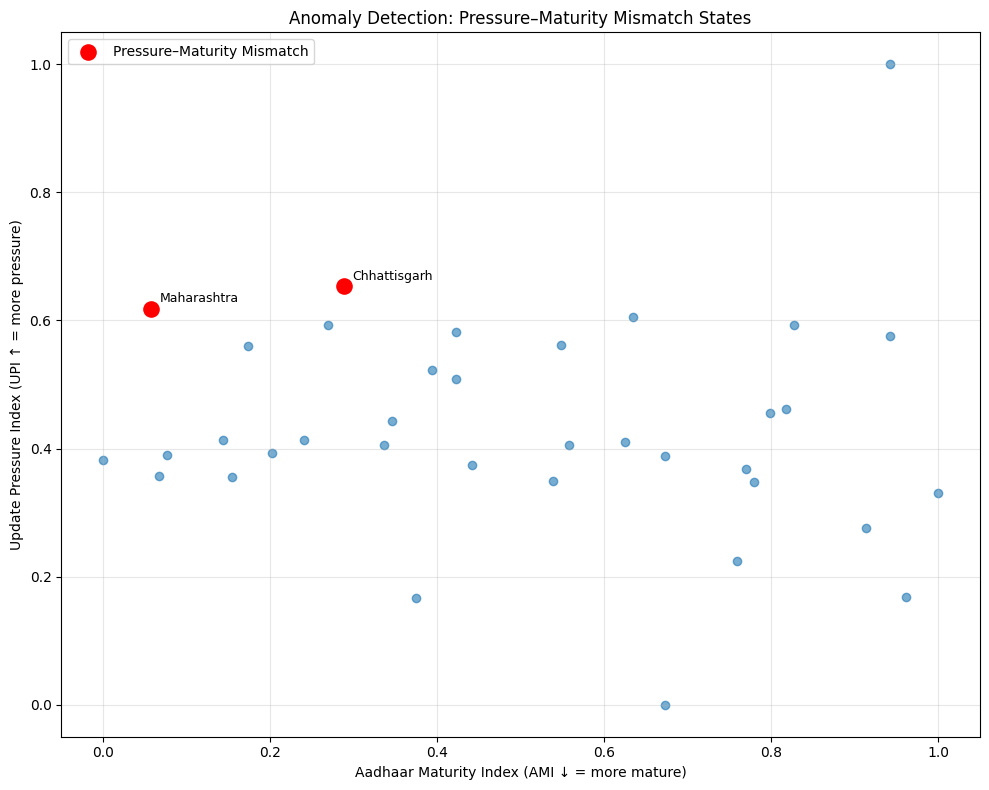

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Base scatter
plt.scatter(
    state_master["AMI"],
    state_master["UPI"],
    alpha=0.6
)

# Highlight anomaly states
anomaly_mask = (state_master["UPI"] > 0.6) & (state_master["AMI"] < 0.3)

plt.scatter(
    state_master.loc[anomaly_mask, "AMI"],
    state_master.loc[anomaly_mask, "UPI"],
    color="red",
    s=120,
    label="Pressure–Maturity Mismatch"
)

# Annotate anomalies
for _, row in state_master.loc[anomaly_mask].iterrows():
    plt.text(row["AMI"]+0.01, row["UPI"]+0.01, row["state"], fontsize=9)

plt.xlabel("Aadhaar Maturity Index (AMI ↓ = more mature)")
plt.ylabel("Update Pressure Index (UPI ↑ = more pressure)")
plt.title("Anomaly Detection: Pressure–Maturity Mismatch States")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


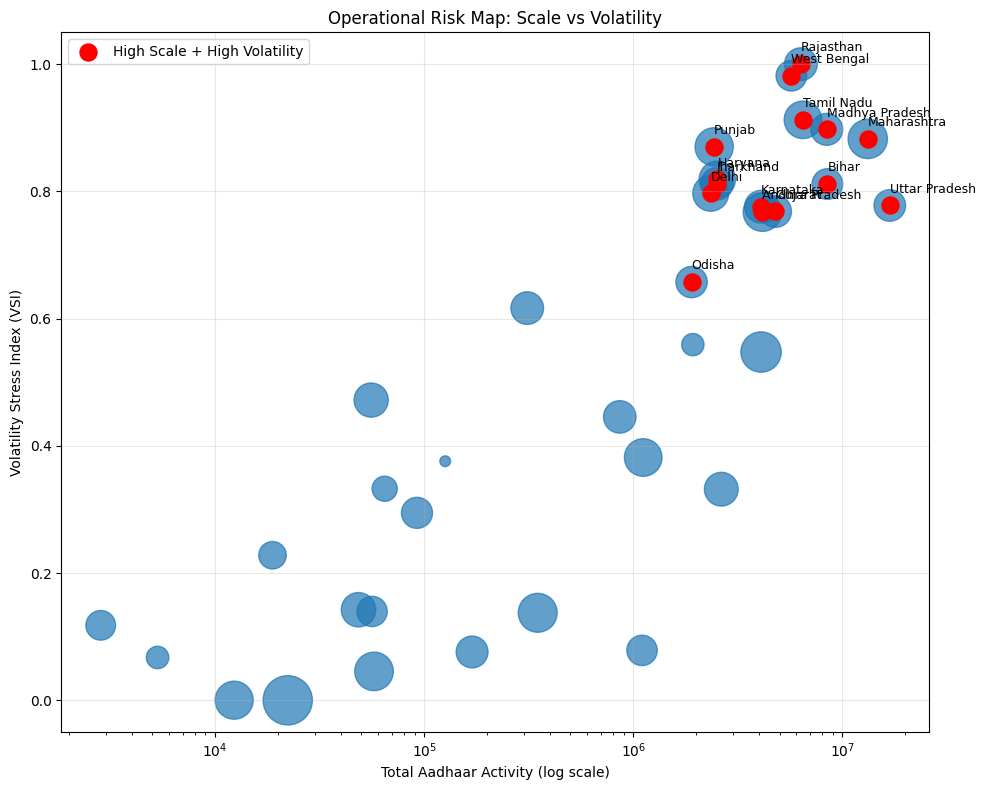

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    state_master["Total_Activity"],
    state_master["VSI"],
    s=(state_master["UPI"] + 0.05) * 1200,
    alpha=0.7
)

# Highlight risky zone
risk_mask = (state_master["VSI"] > 0.6) & (state_master["Total_Activity"] > state_master["Total_Activity"].median())

plt.scatter(
    state_master.loc[risk_mask, "Total_Activity"],
    state_master.loc[risk_mask, "VSI"],
    color="red",
    s=150,
    label="High Scale + High Volatility"
)

for _, row in state_master.loc[risk_mask].iterrows():
    plt.text(row["Total_Activity"], row["VSI"]+0.02, row["state"], fontsize=9)

plt.xscale("log")
plt.xlabel("Total Aadhaar Activity (log scale)")
plt.ylabel("Volatility Stress Index (VSI)")
plt.title("Operational Risk Map: Scale vs Volatility")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


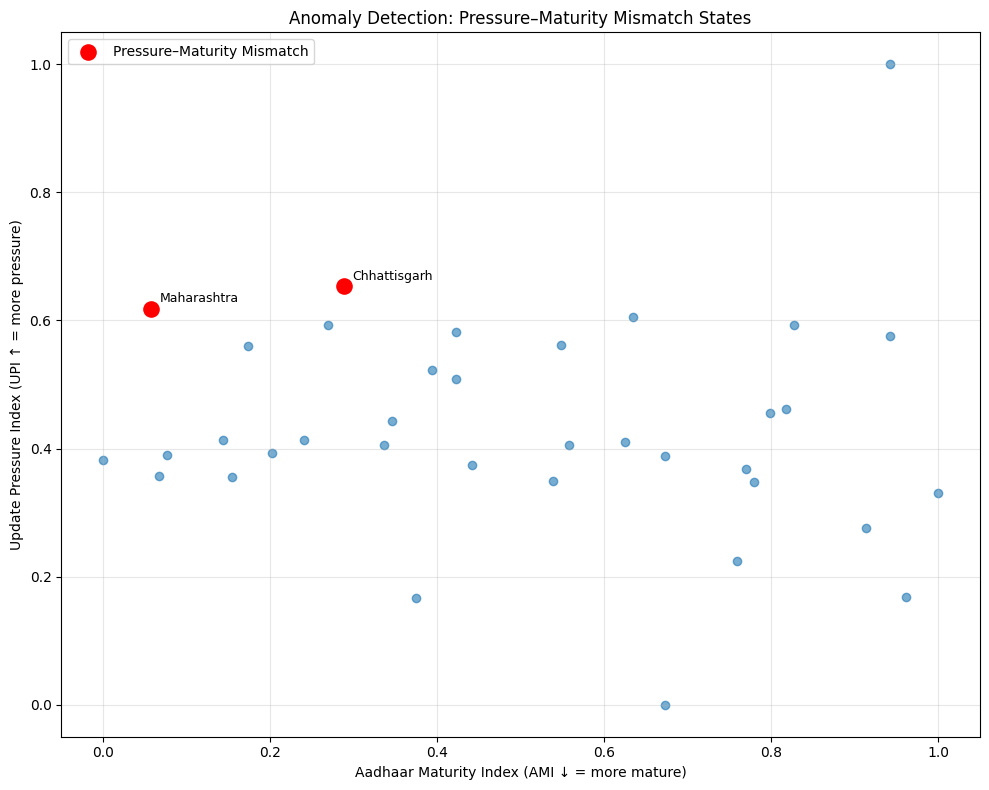

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Base scatter
plt.scatter(
    state_master["AMI"],
    state_master["UPI"],
    alpha=0.6
)

# Highlight anomaly states
anomaly_mask = (state_master["UPI"] > 0.6) & (state_master["AMI"] < 0.3)

plt.scatter(
    state_master.loc[anomaly_mask, "AMI"],
    state_master.loc[anomaly_mask, "UPI"],
    color="red",
    s=120,
    label="Pressure–Maturity Mismatch"
)

# Annotate anomalies
for _, row in state_master.loc[anomaly_mask].iterrows():
    plt.text(row["AMI"]+0.01, row["UPI"]+0.01, row["state"], fontsize=9)

plt.xlabel("Aadhaar Maturity Index (AMI ↓ = more mature)")
plt.ylabel("Update Pressure Index (UPI ↑ = more pressure)")
plt.title("Anomaly Detection: Pressure–Maturity Mismatch States")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


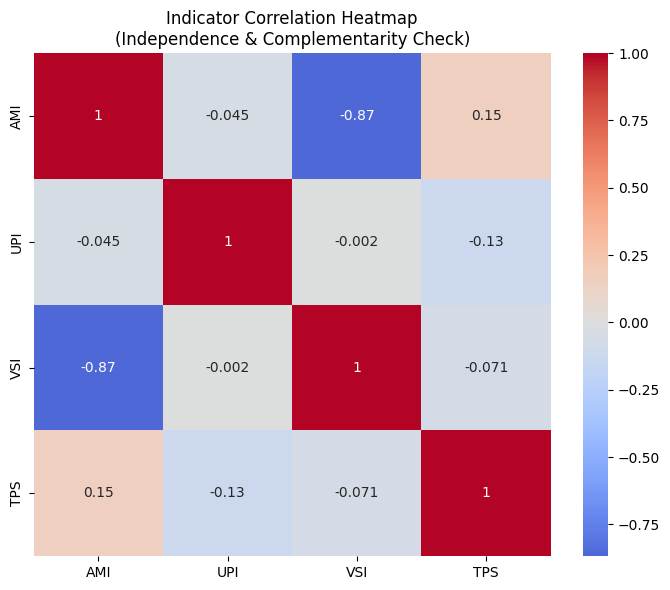

In [ ]:
import seaborn as sns

plt.figure(figsize=(7, 6))

indicator_corr = state_master[["AMI", "UPI", "VSI", "TPS"]].corr()

sns.heatmap(
    indicator_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Indicator Correlation Heatmap\n(Independence & Complementarity Check)")
plt.tight_layout()
plt.show()


In [ ]:
def map_policy_action(row):
    # 1. Mature but stressed → capacity & decentralization
    if row["AMI"] < 0.3 and row["UPI"] > 0.6 and row["VSI"] > 0.5:
        return (
            "Mature–Overloaded",
            "Expand update capacity, decentralize service points, introduce load-balancing"
        )

    # 2. Mature and stable → quality & optimization
    if row["AMI"] < 0.3 and row["VSI"] < 0.3:
        return (
            "Stable Mature",
            "Optimize operations, invest in fraud detection & service quality"
        )

    # 3. Expansion states → enrollment focus
    if row["AMI"] > 0.7 and row["UPI"] < 0.4:
        return (
            "Expansion Phase",
            "Increase enrollment infrastructure and outreach programs"
        )

    # 4. Unpredictable systems → monitoring
    if row["TPS"] < 0.3:
        return (
            "Unpredictable System",
            "Increase monitoring, investigate administrative or reporting irregularities"
        )

    # 5. Everything else
    return (
        "Transitional",
        "Balanced investment across enrollment and update services"
    )


In [ ]:
state_master[["Governance_Status", "Policy_Action"]] = (
    state_master.apply(
        lambda row: map_policy_action(row),
        axis=1,
        result_type="expand"
    )
)


In [ ]:
policy_table = state_master[
    [
        "state",
        "Governance_Status",
        "Policy_Action",
        "AMI",
        "UPI",
        "VSI",
        "TPS"
    ]
].sort_values("Governance_Status")

policy_table.head()


,state,Governance_Status,Policy_Action,AMI,UPI,VSI,TPS
17,Ladakh,Expansion Phase,Increase enrollment infrastructure and outreac...,0.961538,0.168259,0.067323,0.995594
23,Mizoram,Expansion Phase,Increase enrollment infrastructure and outreac...,0.769231,0.367347,0.294674,0.679790
24,Nagaland,Expansion Phase,Increase enrollment infrastructure and outreac...,0.759615,0.224094,0.332577,0.683967
29,Sikkim,Expansion Phase,Increase enrollment infrastructure and outreac...,0.913462,0.276655,0.228038,0.997551
18,Lakshadweep,Expansion Phase,Increase enrollment infrastructure and outreac...,1.000000,0.330397,0.117868,0.000000


In [ ]:
policy_table.to_csv(
    "/content/drive/MyDrive/uidai/analysis/final_policy_impact_table.csv",
    index=False
)


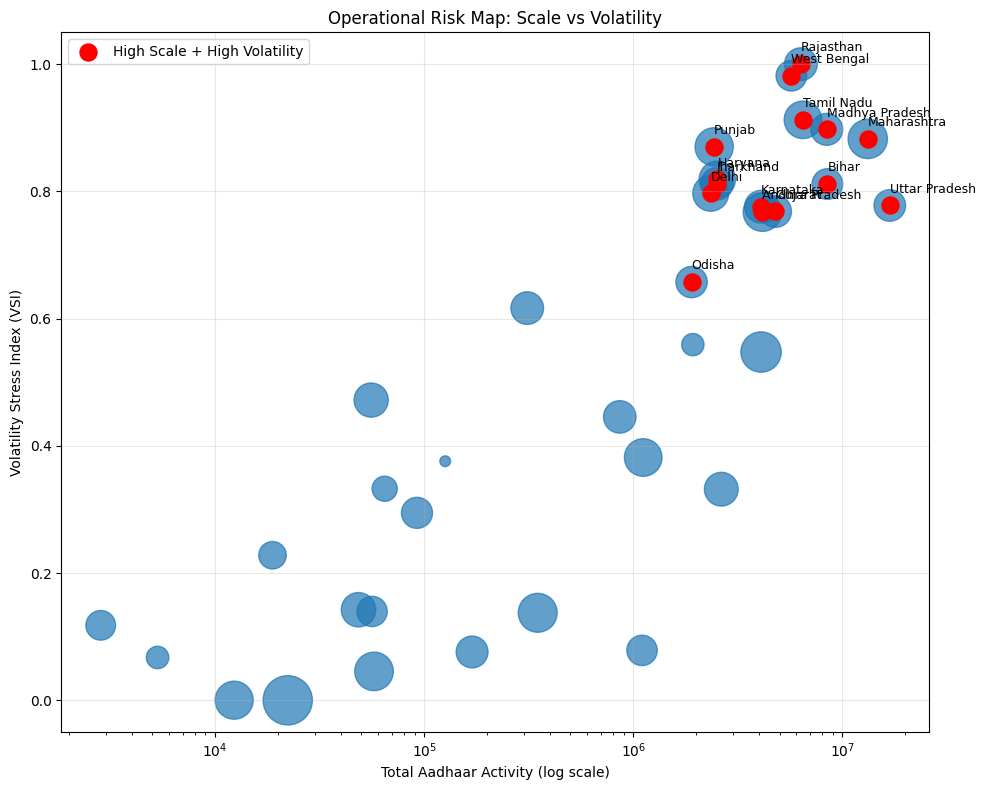

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    state_master["Total_Activity"],
    state_master["VSI"],
    s=(state_master["UPI"] + 0.05) * 1200,
    alpha=0.7
)

# Highlight risky zone
risk_mask = (state_master["VSI"] > 0.6) & (state_master["Total_Activity"] > state_master["Total_Activity"].median())

plt.scatter(
    state_master.loc[risk_mask, "Total_Activity"],
    state_master.loc[risk_mask, "VSI"],
    color="red",
    s=150,
    label="High Scale + High Volatility"
)

for _, row in state_master.loc[risk_mask].iterrows():
    plt.text(row["Total_Activity"], row["VSI"]+0.02, row["state"], fontsize=9)

plt.xscale("log")
plt.xlabel("Total Aadhaar Activity (log scale)")
plt.ylabel("Volatility Stress Index (VSI)")
plt.title("Operational Risk Map: Scale vs Volatility")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
